In [1]:
# Google Drive'ı bağla
from google.colab import drive
drive.mount('/content/drive')

# Zip dosyasının yolu
zip_path = "/content/drive/My Drive/images_clahe.zip"
extract_path = "/content"

# Zip'i çıkart
import zipfile, os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Kaç dosya çıkartıldığını kontrol et
file_count = sum([len(files) for r, d, files in os.walk(extract_path)])
print(f"Toplam {file_count} dosya çıkartıldı.")


Mounted at /content/drive
Toplam 72493 dosya çıkartıldı.


In [2]:
import os

folder_path = "/content/images_clahe"

# İlk child seviyesindeki dosya sayısı
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(f"İlk child seviyesinde {len(files)} dosya var.")


İlk child seviyesinde 72221 dosya var.


In [3]:
# =============================
# CSV -> Parquet (images_full_clahe ile eşleşen ID'ler)
# Şema: id, L1, L2, L3, L4, image_path
# Kurallar:
#  - Sadece /content/images_full_clahe içindeki (ilk child) ID'ler alınır
#  - Duplicate ID varsa CATEGORY_LEVEL en yüksek olan seçilir (eşitse ilk)
#  - L1=L3.parent, L2=L2.parent, L3=L1.parent, L4=NAME (sağdan sola)
#  - L3/L4 boşsa boş bırakılır (NaN)
# =============================

!pip -q install pandas pyarrow > /dev/null

import os, re
import pandas as pd
from google.colab import drive

# -------- Drive mount --------
drive.mount('/content/drive')

# -------- Ayarlar --------
USER_CSV_PATH = "/content/drive/My Drive/top_25_per_category_updated2.csv"   # Kullanıcının verdiği ifade
IMAGES_DIR    = "/content/images_clahe"                    # İlk child taranacak
OUT_PARQUET   = "/content/data.parquet"

# "my drive / ..." ifadesini güvenle Colab yoluna çevir
def to_drive_path(user_path: str) -> str:
    cleaned = re.sub(r"\s+", " ", user_path.strip())
    lowered = cleaned.lower()
    prefix = "my drive /"
    if lowered.startswith(prefix):
        # "my drive / X" -> "/content/drive/My Drive/X"
        return "/content/drive/My Drive/" + cleaned[len(prefix):]
    return cleaned  # zaten mutlak yol olabilir

csv_path = to_drive_path(USER_CSV_PATH)

# -------- Klasördeki ID'leri (ilk child) oku --------
all_entries = os.listdir(IMAGES_DIR)
files = [f for f in all_entries if os.path.isfile(os.path.join(IMAGES_DIR, f))]

# id -> gerçek tam yol (uzantı neyse onu koru). Duplicate dosya varsa ilkini al.
def stem(filename: str) -> str:
    return os.path.splitext(filename)[0]

id_to_path = {}
for f in files:
    file_id = stem(f)
    id_to_path.setdefault(file_id, os.path.join(IMAGES_DIR, f))

available_ids = set(id_to_path.keys())

# -------- CSV oku --------
df = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]

required = [
    "CATEGORY_NAME",
    "PARENT_CATEGORY_NAME1",
    "PARENT_CATEGORY_NAME2",
    "PARENT_CATEGORY_NAME3",
    "CATEGORY_LEVEL",
    "group_id",
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Eksik sütun(lar): {missing}")

# group_id -> "id" (dosya adlarıyla eşleşmesi için string normalizasyonu)
def normalize_id(x):
    s = str(x).strip()
    # 123456.0 gibi durumları güvenle tamsayıya çevir
    if re.fullmatch(r"\d+(\.0+)?", s):
        return str(int(float(s)))
    # Aksi halde tüm rakamları toplayalım (ID'ler sayısal varsayılıyor)
    digits = re.sub(r"\D", "", s)
    return digits if digits else s

df["id"] = df["group_id"].apply(normalize_id)

# Sadece klasörde gerçekten bulunan ID'ler
df = df[df["id"].isin(available_ids)].copy()

# CATEGORY_LEVEL sayısala; NaN'leri -1 yapalım (karşılaştırma için)
df["CATEGORY_LEVEL_num"] = pd.to_numeric(df["CATEGORY_LEVEL"], errors="coerce").fillna(-1)

# Duplicate ID'lerde en yüksek CATEGORY_LEVEL'ı seç (eşitse ilk görüleni)
df_sorted = df.sort_index()  # eşitlikte ilk görülenin kalması için
best_idx = df_sorted.groupby("id")["CATEGORY_LEVEL_num"].idxmax()
df_dedup = df_sorted.loc[best_idx].copy()

# image_path eşlemesi (gerçek dosya yolu, uzantıyı korur)
df_dedup["image_path"] = df_dedup["id"].map(id_to_path)

# Çıkış şeması
df_out = pd.DataFrame({
    "id": df_dedup["id"],
    "L1": df_dedup["PARENT_CATEGORY_NAME3"],
    "L2": df_dedup["PARENT_CATEGORY_NAME2"],
    "L3": df_dedup["PARENT_CATEGORY_NAME1"],
    "L4": df_dedup["CATEGORY_NAME"],
    "image_path": df_dedup["image_path"],
})

# Parquet yaz
df_out.to_parquet(OUT_PARQUET, index=False)

# -------- Özet bilgi --------
total_files_first_child = len(files)
unique_ids_in_folder   = len(available_ids)
rows_after_filter      = len(df)           # CSV'den, klasörde var olan ID'ler
rows_after_dedup       = len(df_dedup)
final_rows             = len(df_out)

print("==================================================================")
print("data.parquet ÖZET")
print("------------------------------------------------------------------")
print(f"Klasör            : {IMAGES_DIR}")
print(f"İlk child dosya   : {total_files_first_child}")
print(f"Eşleşen benzersiz ID sayısı (klasörde): {unique_ids_in_folder}")
print(f"CSV yolu          : {csv_path}")
print(f"Filtre sonrası satır (ID klasörde var): {rows_after_filter}")
print(f"Duplicate çözümü sonrası satır        : {rows_after_dedup} "
      f"(çözümlenen dup: {rows_after_filter - rows_after_dedup})")
print(f"Yazılan satır sayısı                  : {final_rows}")
print(f"Parquet çıktısı  : {OUT_PARQUET}")
print("------------------------------------------------------------------")
print("Sütun tipleri:")
print(df_out.dtypes)
print("------------------------------------------------------------------")
print("İlk 5 satır (örnek):")
print(df_out.head(5).to_string(index=False))
print("==================================================================")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data.parquet ÖZET
------------------------------------------------------------------
Klasör            : /content/images_clahe
İlk child dosya   : 72221
Eşleşen benzersiz ID sayısı (klasörde): 72215
CSV yolu          : /content/drive/My Drive/top_25_per_category_updated2.csv
Filtre sonrası satır (ID klasörde var): 72274
Duplicate çözümü sonrası satır        : 72215 (çözümlenen dup: 59)
Yazılan satır sayısı                  : 72215
Parquet çıktısı  : /content/data.parquet
------------------------------------------------------------------
Sütun tipleri:
id            object
L1            object
L2            object
L3            object
L4            object
image_path    object
dtype: object
------------------------------------------------------------------
İlk 5 satır (örnek):
     id                            L1                  L2                    L3  L4  

In [4]:
import pandas as pd

# Parquet dosyasını oku
df = pd.read_parquet("/content/data.parquet")

# Sütun isimleri ve tipleri
print("=== Sütunlar ve Veri Tipleri ===")
print(df.dtypes)
print()

# Null değerler
print("=== Null Değer Sayıları ===")
print(df.isnull().sum())
print()

# Satır ve sütun sayısı
print("=== Boyutlar ===")
print(df.shape)
print()

# İlk 5 satır örnek
print("=== İlk 5 Satır ===")
print(df.head())
print()

# Sayısal sütunlar için özet istatistikler
print("=== Özet İstatistikler (sayısal sütunlar) ===")
print(df.describe())


=== Sütunlar ve Veri Tipleri ===
id            object
L1            object
L2            object
L3            object
L4            object
image_path    object
dtype: object

=== Null Değer Sayıları ===
id                0
L1                0
L2                0
L3             4931
L4            44890
image_path        0
dtype: int64

=== Boyutlar ===
(72215, 6)

=== İlk 5 Satır ===
        id                             L1                   L2  \
0  1000018  Yürüteç & Yürüme Yardımcıları  Yürüme Yardımcıları   
1  1000050              Bebek Oyuncakları      1-3 Yaş Oyuncak   
2  1000138            Yapı Market & Bahçe     Bahçe Makineleri   
3  1000158            Yapı Market & Bahçe     Bahçe Makineleri   
4  1000183            Yapı Market & Bahçe     Bahçe Makineleri   

                      L3    L4                         image_path  
0                   None  None  /content/images_clahe/1000018.jpg  
1                   None  None  /content/images_clahe/1000050.jpg  
2  Toprak Burg

In [5]:
# -*- coding: utf-8 -*-
"""
Hiyerarşik Kategori Tahmini için Veri Ön İşleme
- Parquet'ten hiyerarşik etiketler çıkarma
- Label encoding + mapping dosyaları
- Train/val split
- JSONL export for hierarchical classification
"""

import pandas as pd
import numpy as np
import json
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from pathlib import Path

# ---------------------------
# Paths
# ---------------------------
DATA_PARQUET = "/content/data.parquet"
OUTPUT_DIR = "/content/prep_hierarchical"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def log(s): print(s, flush=True)

# ---------------------------
# Label mapping & encoding
# ---------------------------
class HierarchicalLabelEncoder:
    def __init__(self):
        self.label_to_idx = {}
        self.idx_to_label = {}
        self.level_counts = {}

    def fit_level(self, level_name, labels):
        """Bir seviye için label mapping oluştur"""
        unique_labels = sorted([str(x) for x in labels.dropna().unique()])

        # 'Unknown' class her seviye için 0 index
        mapping = {'<UNK>': 0}
        mapping.update({label: i+1 for i, label in enumerate(unique_labels)})

        self.label_to_idx[level_name] = mapping
        self.idx_to_label[level_name] = {v: k for k, v in mapping.items()}
        self.level_counts[level_name] = len(mapping)

        log(f"[{level_name}] {len(unique_labels)} unique labels + UNK = {len(mapping)} total classes")
        return mapping

    def encode_level(self, level_name, labels):
        """Bir seviye için encoding"""
        mapping = self.label_to_idx[level_name]
        return labels.fillna('<UNK>').astype(str).map(mapping).fillna(0).astype(int)

    def save_mappings(self, path):
        """Mapping dosyalarını kaydet"""
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({
                'label_to_idx': self.label_to_idx,
                'idx_to_label': self.idx_to_label,
                'level_counts': self.level_counts
            }, f, ensure_ascii=False, indent=2)
        log(f"Label mappings saved to {path}")

# ---------------------------
# Dataset analytics
# ---------------------------
def analyze_hierarchy(df):
    """Hiyerarşik veri yapısını analiz et"""
    log("=== HİYERARŞİK VERİ ANALİZİ ===")

    # Her seviyedeki dolu veri oranları
    total = len(df)
    for level in ['L1', 'L2', 'L3', 'L4']:
        non_null = df[level].notna().sum()
        pct = (non_null / total) * 100
        log(f"{level}: {non_null:,}/{total:,} (%{pct:.1f}) dolu")

    # Seviye kombinasyonları
    log("\n=== SEVİYE KOMBİNASYONLARI ===")
    combinations = df.groupby(['L1', 'L2', 'L3', 'L4']).size().reset_index(name='count')
    combinations = combinations.sort_values('count', ascending=False)
    log(f"Toplam unique kombinasyon: {len(combinations)}")
    log("En sık 10 kombinasyon:")
    for i, row in combinations.head(10).iterrows():
        l1, l2, l3, l4, cnt = row['L1'], row['L2'], row['L3'], row['L4'], row['count']
        combo = f"{l1} > {l2}"
        if pd.notna(l3): combo += f" > {l3}"
        if pd.notna(l4): combo += f" > {l4}"
        log(f"  {cnt:4d}: {combo}")

    # Depth distribution
    log("\n=== DERINLIK DAĞILIMI ===")
    def get_depth(row):
        if pd.notna(row['L4']): return 4
        if pd.notna(row['L3']): return 3
        return 2  # L1, L2 her zaman dolu

    depths = df.apply(get_depth, axis=1)
    depth_counts = depths.value_counts().sort_index()
    for depth, count in depth_counts.items():
        pct = (count / total) * 100
        log(f"Derinlik {depth}: {count:,} (%{pct:.1f})")

# ---------------------------
# Train/val split with stratification
# ---------------------------
def stratified_train_val_test_split(df, val_size=0.1, test_size=0.1, random_state=42):
    """80% train, 10% val, 10% test stratified split"""

    # L1+L2 kombinasyonu stratification key olarak kullan
    df['strat_key'] = df['L1'].astype(str) + " | " + df['L2'].astype(str)

    # Çok az sample'ı olan kombinasyonları 'OTHER' gruba at
    key_counts = df['strat_key'].value_counts()
    min_samples = max(3, int(1 / min(val_size, test_size)))  # en az 3 sample

    rare_keys = key_counts[key_counts < min_samples].index
    df.loc[df['strat_key'].isin(rare_keys), 'strat_key'] = 'OTHER_RARE'

    # Önce train ve temp (val+test) ayır
    temp_size = val_size + test_size  # 0.2
    train_df, temp_df = train_test_split(
        df,
        test_size=temp_size,
        random_state=random_state,
        stratify=df['strat_key']
    )

    # Temp'i val ve test olarak ayır
    # temp içinde val_size / (val_size + test_size) = 0.1 / 0.2 = 0.5
    val_ratio_in_temp = val_size / temp_size

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_in_temp),  # 0.5 (test için)
        random_state=random_state,
        stratify=temp_df['strat_key']
    )

    # Temporary column'u kaldır
    train_df = train_df.drop('strat_key', axis=1).reset_index(drop=True)
    val_df = val_df.drop('strat_key', axis=1).reset_index(drop=True)
    test_df = test_df.drop('strat_key', axis=1).reset_index(drop=True)

    log(f"Train: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
    log(f"Val:   {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
    log(f"Test:  {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

    return train_df, val_df, test_df

# ---------------------------
# JSONL export for training
# ---------------------------
def create_hierarchical_jsonl(df, encoder, output_path, split_name):
    """Hiyerarşik eğitim için JSONL oluştur"""
    data_list = []

    for idx, row in df.iterrows():
        # Labels encode et
        labels = {}
        for level in ['L1', 'L2', 'L3', 'L4']:
            labels[f"{level}_idx"] = int(encoder.encode_level(level, pd.Series([row[level]])).iloc[0])
            labels[f"{level}_name"] = str(row[level]) if pd.notna(row[level]) else '<UNK>'

        # Depth hesapla
        depth = 4 if pd.notna(row['L4']) else (3 if pd.notna(row['L3']) else 2)

        item = {
            "image_path": row['image_path'],
            "id": str(row['id']),
            "depth": depth,
            **labels,
            "weight": 1.0  # Uniform weight, istersen depth'e göre ağırlıklandırabilirsin
        }
        data_list.append(item)

    # JSONL yaz
    with open(output_path, 'w', encoding='utf-8') as f:
        for item in data_list:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')

    log(f"[{split_name}] {len(data_list):,} items written to {output_path}")

    # Depth dağılımı
    depth_dist = Counter([item['depth'] for item in data_list])
    for depth in sorted(depth_dist.keys()):
        count = depth_dist[depth]
        pct = (count / len(data_list)) * 100
        log(f"  Depth {depth}: {count:,} (%{pct:.1f})")

# ---------------------------
# Weighted sampling strategy
# ---------------------------
def calculate_sample_weights(df):
    """Class imbalance için sample weights hesapla"""
    # L1 seviyesindeki dağılıma göre ağırlıklandır
    l1_counts = df['L1'].value_counts()
    l1_weights = 1.0 / l1_counts
    l1_weights = l1_weights / l1_weights.sum() * len(l1_weights)  # normalize

    weights = df['L1'].map(l1_weights)

    log(f"Sample weights: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")
    return weights

# ---------------------------
# Stats export
# ---------------------------
def export_stats(encoder, train_df, val_df, test_df, output_dir):
    """Eğitim için gerekli istatistikleri export et"""

    stats = {
        "dataset_info": {
            "total_samples": int(len(train_df) + len(val_df) + len(test_df)),
            "train_samples": int(len(train_df)),
            "val_samples": int(len(val_df)),
            "test_samples": int(len(test_df)),
            "image_path_prefix": "/content/images/"
        },
        "class_counts": {k: int(v) for k, v in encoder.level_counts.items()},
        "level_info": {}
    }

    # Her seviye için detaylar
    for level in ['L1', 'L2', 'L3', 'L4']:
        train_dist = train_df[level].value_counts()
        val_dist = val_df[level].value_counts()
        test_dist = test_df[level].value_counts()

        stats["level_info"][level] = {
            "unique_classes": int(encoder.level_counts[level]),
            "train_coverage": int(train_df[level].notna().sum()),
            "val_coverage": int(val_df[level].notna().sum()),
            "test_coverage": int(test_df[level].notna().sum()),
            "most_common_train": {k: int(v) for k, v in train_dist.head(5).items()},
            "most_common_val": {k: int(v) for k, v in val_dist.head(5).items()},
            "most_common_test": {k: int(v) for k, v in test_dist.head(5).items()}
        }

    # Tüm objeyi serializable hale getir
    def make_serializable(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {k: make_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [make_serializable(v) for v in obj]
        return obj

    stats = make_serializable(stats)

    stats_path = os.path.join(output_dir, "dataset_stats.json")
    with open(stats_path, 'w', encoding='utf-8') as f:
        json.dump(stats, f, ensure_ascii=False, indent=2)

    log(f"Dataset stats saved to {stats_path}")
    return stats

# ---------------------------
# Drive sync
# ---------------------------
def sync_to_drive():
    try:
        import shutil
        tgt = "/content/drive/MyDrive/hierarchical_data_prep"
        os.makedirs(tgt, exist_ok=True)
        shutil.copytree(OUTPUT_DIR, tgt, dirs_exist_ok=True)
        log(f"Data synced to Drive: {tgt}")
    except Exception as e:
        log(f"Drive sync failed: {e}")

# ---------------------------
# Main pipeline
# ---------------------------
def main():
    log("=== HİYERAR İK VERİ ÖN İŞLEME BAŞLADI ===")

    # 1. Veriyi yükle
    df = pd.read_parquet(DATA_PARQUET)
    log(f"Loaded data: {len(df):,} rows")

    # 2. Veri kalitesi kontrolü
    missing_images = ~df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)
    if missing_images.sum() > 0:
        log(f"⚠️  {missing_images.sum()} missing image files - removing from dataset")
        df = df[~missing_images].reset_index(drop=True)

    # 3. Hierarchy analizi
    analyze_hierarchy(df)

    # 4. Label encoding
    encoder = HierarchicalLabelEncoder()
    for level in ['L1', 'L2', 'L3', 'L4']:
        encoder.fit_level(level, df[level])

    encoder.save_mappings(os.path.join(OUTPUT_DIR, "label_mappings.json"))

    # 5. Train/val/test split (updated)
    train_df, val_df, test_df = stratified_train_val_test_split(
        df, val_size=0.1, test_size=0.1, random_state=42
    )

    # 7. JSONL export (test seti dahil)
    train_jsonl = os.path.join(OUTPUT_DIR, "pairs_train.jsonl")
    val_jsonl = os.path.join(OUTPUT_DIR, "pairs_val.jsonl")
    test_jsonl = os.path.join(OUTPUT_DIR, "pairs_test.jsonl")  # Test JSONL

    create_hierarchical_jsonl(train_df, encoder, train_jsonl, "TRAIN")
    create_hierarchical_jsonl(val_df, encoder, val_jsonl, "VAL")
    create_hierarchical_jsonl(test_df, encoder, test_jsonl, "TEST")  # Test export

    # 8. Stats kaydet (test dahil)
    stats = export_stats(encoder, train_df, val_df, test_df, OUTPUT_DIR)

    # 9. Drive sync
    sync_to_drive()

    # 10. Summary
    log("\n=== ÖZET ===")
    log(f"Output directory: {OUTPUT_DIR}")
    log(f"Train JSONL: {train_jsonl}")
    log(f"Val JSONL: {val_jsonl}")
    log(f"Label mappings: {OUTPUT_DIR}/label_mappings.json")
    log(f"Stats: {OUTPUT_DIR}/dataset_stats.json")

    print("\n=== CLASS COUNTS PER LEVEL ===")
    for level, count in encoder.level_counts.items():
        print(f"{level}: {count} classes")

    print(f"\nVeri ön işleme tamamlandı!")

if __name__ == "__main__":
    main()

=== HİYERAR İK VERİ ÖN İŞLEME BAŞLADI ===
Loaded data: 72,215 rows
=== HİYERARŞİK VERİ ANALİZİ ===
L1: 72,215/72,215 (%100.0) dolu
L2: 72,215/72,215 (%100.0) dolu
L3: 67,284/72,215 (%93.2) dolu
L4: 27,325/72,215 (%37.8) dolu

=== SEVİYE KOMBİNASYONLARI ===
Toplam unique kombinasyon: 1411
En sık 10 kombinasyon:
    20: Çocuk Giyim & Aksesuar > Kız Çocuk > İç Giyim & Uyku Giyim > İç Çamaşırı
    20: Aksesuar & Tuning > Oto Bakım > Boya & Parlatıcı > Boya
    20: Yedek Parça > Oto Elektrik > Akü Takviye Kablosu ve Sarj Cihazı > Akü Sarj Cihazı
    20: Yedek Parça > Oto Elektrik > Akü Takviye Kablosu ve Sarj Cihazı > Akü Takviye Kablosu
    20: Yedek Parça > Oto Elektrik > Korna & Siren > Havalı Korna
    20: Yedek Parça > Oto Elektrik > Korna & Siren > Kompresörlü Korna
    20: Yedek Parça > Oto Elektrik > Korna & Siren > Normal Sesli Korna
    20: Yedek Parça > Oto Elektrik > Korna & Siren > Siren
    20: Yedek Parça > Oto Elektrik > Oto Cam > Cam Açma Kolu
    20: Yedek Parça > Oto Elek

In [6]:
!pip install open-clip-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


In [7]:
# -*- coding: utf-8 -*-
"""
Hierarchical Learning - Cascade LoRA Training
L1 -> L2 -> L3 hiyerarşik bağımlılık ile eğitim
"""

import os, json, math, random, gc, time, threading, traceback
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from pathlib import Path
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from tqdm import tqdm
import open_clip
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support, classification_report
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# Colab Setup
# ---------------------------
def setup_colab_environment():
    """Setup Colab environment"""
    # Mount Google Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("✅ Google Drive mounted successfully")
    except ImportError:
        print("⚠️ Not in Colab environment, skipping drive mount")

    # Install required packages
    try:
        import open_clip
        print("✅ open_clip already installed")
    except ImportError:
        print("📦 Installing open_clip...")
        os.system("pip install open-clip-torch")

    # GPU check
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print(f"✅ GPU available: {gpu_name}")
        print(f"🔥 CUDA version: {torch.version.cuda}")
    else:
        print("⚠️ No GPU available, using CPU")

    return torch.cuda.is_available()

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

def log(s):
    print(f"[{time.strftime('%H:%M:%S')}] {s}", flush=True)

# A100/T4 optimizations
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except:
        pass

def amp_dtype():
    if DEVICE == "cuda":
        major, _ = torch.cuda.get_device_capability()
        if major >= 8 and torch.cuda.is_bf16_supported():
            return torch.bfloat16
    return torch.float16

# ---------------------------
# Data paths - Colab friendly
# ---------------------------
def setup_data_paths():
    """Setup data paths for Colab"""
    base_dir = "/content"

    paths = {
        'prep_dir': f"{base_dir}/prep_hierarchical",
        'train_jsonl': f"{base_dir}/prep_hierarchical/pairs_train.jsonl",
        'val_jsonl': f"{base_dir}/prep_hierarchical/pairs_val.jsonl",
        'test_jsonl': f"{base_dir}/prep_hierarchical/pairs_test.jsonl",  # Yeni eklendi
        'label_mappings': f"{base_dir}/prep_hierarchical/label_mappings.json",
        'checkpoint_dir': f"{base_dir}/hierarchical_training_checkpoints"
    }

    # Create directories
    os.makedirs(paths['checkpoint_dir'], exist_ok=True)

    # Check if data exists
    for key, path in paths.items():
        if 'dir' in key:
            continue
        if os.path.exists(path):
            log(f"✅ Found: {key}")
        else:
            log(f"❌ Missing: {key}")
            if key == 'train_jsonl':
                raise FileNotFoundError(f"Training data not found at {path}")

    return paths

# ---------------------------
# Model loading
# ---------------------------
def load_marqo_model():
    """Load Marqo visual model"""
    model_id = "hf-hub:Marqo/marqo-ecommerce-embeddings-L"
    log(f"🔄 Loading model: {model_id}")

    try:
        model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
            model_id, device=DEVICE, precision='fp32'
        )

        model.eval()
        for param in model.parameters():
            param.requires_grad = False

        # Test embedding dimension
        with torch.no_grad():
            dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
            embed = model.encode_image(dummy)
            embed_dim = embed.shape[-1]

        log(f"✅ Model loaded, embedding dim: {embed_dim}")
        return model, preprocess_train, preprocess_val

    except Exception as e:
        log(f"❌ Model loading failed: {e}")
        raise

# ---------------------------
# LoRA implementation
# ---------------------------
class LoRALinear(nn.Module):
    def __init__(self, base_layer, r=16, alpha=16, dropout=0.0):
        super().__init__()
        self.base_layer = base_layer

        for param in base_layer.parameters():
            param.requires_grad = False

        self.r = r
        self.alpha = alpha
        self.scale = alpha / r
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        in_features = base_layer.in_features
        out_features = base_layer.out_features

        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        base_out = self.base_layer(x)
        lora_out = self.lora_B(self.dropout(self.lora_A(x)))
        return base_out + self.scale * lora_out

def inject_lora(model, r=20, alpha=40, dropout=0.15):
    """Inject LoRA into visual encoder"""
    target_modules = ["attn.qkv", "attn.proj", "mlp.fc1", "mlp.fc2"]

    lora_count = 0
    named_modules = dict(model.named_modules())

    for name, module in model.named_modules():
        should_adapt = any(target in name for target in target_modules)

        if should_adapt and isinstance(module, nn.Linear):
            parent_name = '.'.join(name.split('.')[:-1])
            if parent_name in named_modules:
                parent = named_modules[parent_name]
                attr_name = name.split('.')[-1]

                lora_layer = LoRALinear(module, r=r, alpha=alpha, dropout=dropout)
                setattr(parent, attr_name, lora_layer)
                lora_count += 1

    log(f"✅ LoRA injected into {lora_count} modules")
    return model

def get_lora_params(model):
    """Get LoRA parameters for optimizer"""
    params = []
    for module in model.modules():
        if isinstance(module, LoRALinear):
            params.extend([module.lora_A.weight, module.lora_B.weight])
    return params

# ---------------------------
# Hierarchical Cascade Head
# ---------------------------
class HierarchicalCascadeHead(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=512, level_counts=None,
                 dropout=0.15, hierarchy_map=None):
        super().__init__()

        if level_counts is None:
            level_counts = {'L1': 85, 'L2': 581, 'L3': 2270}

        self.level_counts = level_counts
        self.hierarchy_map = hierarchy_map or {}

        # Shared features
        self.shared = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # L1 Head - bağımsız
        self.l1_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, level_counts['L1'])
        )

        # L2 Head - L1 çıktısını kullanır
        self.l2_head = nn.Sequential(
            nn.Linear(hidden_dim + level_counts['L1'], hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, level_counts['L2'])
        )

        # L3 Head - L1 ve L2 çıktılarını kullanır
        self.l3_head = nn.Sequential(
            nn.Linear(hidden_dim + level_counts['L1'] + level_counts['L2'], hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, level_counts['L3'])
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights"""
        for module in [self.l1_head, self.l2_head, self.l3_head]:
            for m in module.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    def forward(self, x, training=True):
        shared = self.shared(x)
        preds = {}

        # L1 prediction - bağımsız
        l1_logits = self.l1_head(shared)
        preds['L1'] = l1_logits

        # L1 çıktısını L2 için kullan
        if training:
            # Eğitim sırasında soft predictions kullan
            l1_probs = F.softmax(l1_logits, dim=-1)
        else:
            # Test sırasında hard predictions kullan
            l1_probs = F.one_hot(l1_logits.argmax(dim=-1), num_classes=self.level_counts['L1']).float()

        l2_input = torch.cat([shared, l1_probs], dim=-1)
        l2_logits = self.l2_head(l2_input)
        preds['L2'] = l2_logits

        # L1 ve L2 çıktılarını L3 için kullan
        if training:
            l2_probs = F.softmax(l2_logits, dim=-1)
        else:
            l2_probs = F.one_hot(l2_logits.argmax(dim=-1), num_classes=self.level_counts['L2']).float()

        l3_input = torch.cat([shared, l1_probs, l2_probs], dim=-1)
        l3_logits = self.l3_head(l3_input)
        preds['L3'] = l3_logits

        return preds

# ---------------------------
# Data loading
# ---------------------------
def load_data_and_mappings(paths):
    """Load data and create mappings including test set"""
    log("📊 Loading data and mappings...")

    # Load label mappings
    with open(paths['label_mappings'], 'r') as f:
        data = json.load(f)
    label_to_idx = data['label_to_idx']
    idx_to_label = data['idx_to_label']
    level_counts = data['level_counts']

    # Create hierarchy mapping if available
    hierarchy_map = {}
    try:
        if 'hierarchy_map' in data:
            hierarchy_map = data['hierarchy_map']
        else:
            log("⚠️ No hierarchy map found, creating from data")
            hierarchy_map = create_hierarchy_map_from_data(paths['train_jsonl'])
    except:
        log("⚠️ Could not create hierarchy map")

    # Load training items
    train_items = []
    with open(paths['train_jsonl'], 'r') as f:
        for line in f:
            item = json.loads(line)
            train_items.append(item)

    # Load validation items
    val_items = []
    with open(paths['val_jsonl'], 'r') as f:
        for line in f:
            item = json.loads(line)
            val_items.append(item)

    # Load test items
    test_items = []
    test_jsonl_path = paths.get('test_jsonl', f"{paths['prep_dir']}/pairs_test.jsonl")
    if os.path.exists(test_jsonl_path):
        with open(test_jsonl_path, 'r') as f:
            for line in f:
                item = json.loads(line)
                test_items.append(item)
        log(f"✅ Loaded {len(test_items)} test samples")
    else:
        log(f"⚠️ Test file not found: {test_jsonl_path}")

    log(f"✅ Loaded {len(train_items)} train, {len(val_items)} val, {len(test_items)} test samples")

    return train_items, val_items, test_items, label_to_idx, idx_to_label, level_counts, hierarchy_map

def create_hierarchy_map_from_data(train_jsonl_path):
    """Create hierarchy mapping from training data"""
    hierarchy = defaultdict(lambda: defaultdict(set))

    with open(train_jsonl_path, 'r') as f:
        for line in f:
            item = json.loads(line)
            l1_idx = item['L1_idx']
            l2_idx = item['L2_idx']
            l3_idx = item['L3_idx']

            hierarchy[l1_idx]['L2'].add(l2_idx)
            hierarchy[l2_idx]['L3'].add(l3_idx)

    # Convert to regular dict
    result = {}
    for l1 in hierarchy:
        result[l1] = {
            'L2': list(hierarchy[l1]['L2']),
            'L3': list(set().union(*[hierarchy[l2]['L3'] for l2 in hierarchy[l1]['L2']]))
        }

    return result

# ---------------------------
# Dataset and loss
# ---------------------------
def safe_load_image(path, preprocess):
    try:
        img = Image.open(path).convert("RGB")
        return preprocess(img)
    except:
        img = Image.new("RGB", (256, 256), color="white")
        return preprocess(img)

class HierarchicalDataset(Dataset):
    def __init__(self, items, preprocess):
        self.items = items
        self.preprocess = preprocess

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = safe_load_image(item["image_path"], self.preprocess)

        labels = {
            'L1': item['L1_idx'],
            'L2': item['L2_idx'],
            'L3': item['L3_idx']
        }

        return img, labels, item['depth']

def collate_fn(batch):
    imgs = torch.stack([item[0] for item in batch])
    labels = {}
    for level in ['L1', 'L2', 'L3']:
        labels[level] = torch.tensor([item[1][level] for item in batch], dtype=torch.long)
    depths = torch.tensor([item[2] for item in batch], dtype=torch.long)
    return imgs, labels, depths

def hierarchical_consistency_loss(predictions, targets, depths, hierarchy_map=None,
                                 consistency_weight=0.3, temperature=0.1):
    """Hierarchical loss with consistency constraints"""
    total_loss = 0.0
    level_losses = {}
    level_accuracies = {}

    # Base classification losses
    for level in ['L1', 'L2', 'L3']:
        level_pred = predictions[level]
        level_target = targets[level]

        # Determine valid samples based on depth
        if level == 'L1':
            valid_mask = depths >= 1
        elif level == 'L2':
            valid_mask = depths >= 2
        elif level == 'L3':
            valid_mask = depths >= 3

        if valid_mask.sum() == 0:
            level_losses[level] = 0.0
            level_accuracies[level] = 0.0
            continue

        valid_pred = level_pred[valid_mask]
        valid_target = level_target[valid_mask]

        # Cross entropy with label smoothing
        smoothing = 0.1 if level == 'L3' else 0.05
        loss = F.cross_entropy(valid_pred / temperature, valid_target,
                              label_smoothing=smoothing)

        level_losses[level] = loss.item()
        level_accuracies[level] = (valid_pred.argmax(dim=1) == valid_target).float().mean().item()

        # Weight by level importance
        level_weight = 1.0 if level in ['L1', 'L2'] else 0.8
        total_loss += level_weight * loss

    # Hierarchical consistency loss
    if hierarchy_map and consistency_weight > 0:
        consistency_loss = 0.0

        # L1-L2 consistency
        l2_mask = depths >= 2
        if l2_mask.sum() > 0:
            l1_pred_probs = F.softmax(predictions['L1'][l2_mask], dim=-1)
            l2_pred_probs = F.softmax(predictions['L2'][l2_mask], dim=-1)
            l1_targets = targets['L1'][l2_mask]

            # For each L1 prediction, encourage L2 to be in valid children
            for i, l1_target in enumerate(l1_targets):
                l1_idx = l1_target.item()
                if l1_idx in hierarchy_map and 'L2' in hierarchy_map[l1_idx]:
                    valid_l2_indices = hierarchy_map[l1_idx]['L2']
                    if valid_l2_indices:
                        # Create mask for valid L2 classes
                        valid_mask = torch.zeros_like(l2_pred_probs[i])
                        valid_mask[valid_l2_indices] = 1.0
                        valid_mask = valid_mask / valid_mask.sum()  # normalize

                        # KL divergence between prediction and valid classes
                        consistency_loss += F.kl_div(
                            F.log_softmax(predictions['L2'][l2_mask][i:i+1], dim=-1),
                            valid_mask.unsqueeze(0),
                            reduction='sum'
                        )

        # L2-L3 consistency (similar logic)
        l3_mask = depths >= 3
        if l3_mask.sum() > 0:
            l2_targets = targets['L2'][l3_mask]

            for i, l2_target in enumerate(l2_targets):
                l2_idx = l2_target.item()
                # Find parent L1 for this L2
                parent_l1 = None
                for l1_idx, children in hierarchy_map.items():
                    if 'L2' in children and l2_idx in children['L2']:
                        parent_l1 = l1_idx
                        break

                if parent_l1 and 'L3' in hierarchy_map[parent_l1]:
                    valid_l3_indices = hierarchy_map[parent_l1]['L3']
                    if valid_l3_indices:
                        valid_mask = torch.zeros(predictions['L3'].shape[-1], device=DEVICE)
                        valid_mask[valid_l3_indices] = 1.0
                        valid_mask = valid_mask / valid_mask.sum()

                        consistency_loss += F.kl_div(
                            F.log_softmax(predictions['L3'][l3_mask][i:i+1], dim=-1),
                            valid_mask.unsqueeze(0),
                            reduction='sum'
                        )

        # Normalize consistency loss
        if l2_mask.sum() > 0 or l3_mask.sum() > 0:
            consistency_loss = consistency_loss / max(l2_mask.sum() + l3_mask.sum(), 1)
            total_loss += consistency_weight * consistency_loss

    return total_loss, level_accuracies

# ---------------------------
# Evaluation
# ---------------------------
def evaluate_model(model, head, dataloader, hierarchy_map=None, idx_to_label=None):
    """Evaluate model with hierarchical predictions"""
    model.eval()
    head.eval()

    total_loss = 0.0
    all_preds = {f'L{i}': [] for i in range(1, 4)}
    all_targets = {f'L{i}': [] for i in range(1, 4)}
    all_depths = []
    consistency_violations = 0
    total_predictions = 0

    with torch.no_grad():
        for imgs, labels, depths in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs = imgs.to(DEVICE)
            labels = {k: v.to(DEVICE) for k, v in labels.items()}
            depths = depths.to(DEVICE)

            with autocast(enabled=(DEVICE=="cuda")):
                features = model.encode_image(imgs)
                # Use inference mode (training=False) for hard predictions
                preds = head(features, training=False)
                loss, _ = hierarchical_consistency_loss(preds, labels, depths, hierarchy_map)

            total_loss += loss.item()

            # Collect predictions and check consistency
            for level in ['L1', 'L2', 'L3']:
                if level == 'L1':
                    mask = depths >= 1
                elif level == 'L2':
                    mask = depths >= 2
                elif level == 'L3':
                    mask = depths >= 3

                if mask.sum() > 0:
                    pred = preds[level][mask].argmax(dim=1).cpu().numpy()
                    target = labels[level][mask].cpu().numpy()
                    all_preds[level].extend(pred)
                    all_targets[level].extend(target)

            # Check hierarchical consistency
            if hierarchy_map:
                for i in range(len(depths)):
                    if depths[i] >= 2:  # Has L2
                        l1_pred = preds['L1'][i].argmax().item()
                        l2_pred = preds['L2'][i].argmax().item()

                        if (l1_pred in hierarchy_map and
                            'L2' in hierarchy_map[l1_pred] and
                            l2_pred not in hierarchy_map[l1_pred]['L2']):
                            consistency_violations += 1
                        total_predictions += 1

            all_depths.extend(depths.cpu().numpy())

    # Calculate detailed metrics
    metrics = {}
    for level in ['L1', 'L2', 'L3']:
        if all_preds[level]:
            y_true = np.array(all_targets[level])
            y_pred = np.array(all_preds[level])

            accuracy = (y_true == y_pred).mean()
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, average='weighted', zero_division=0
            )

            metrics[level] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'samples': len(y_true)
            }
        else:
            metrics[level] = {
                'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0,
                'f1': 0.0, 'samples': 0
            }

    # Overall metrics
    avg_loss = total_loss / len(dataloader)
    consistency_rate = 1.0 - (consistency_violations / max(total_predictions, 1))

    return {
        'loss': avg_loss,
        'metrics': metrics,
        'consistency_rate': consistency_rate,
        'consistency_violations': consistency_violations,
        'total_predictions': total_predictions,
        'depth_distribution': dict(Counter(all_depths))
    }

# ---------------------------
# Training configuration
# ---------------------------
@dataclass
class HierarchicalTrainingConfig:
    lr: float = 2e-4

    lora_r: int = 20
    lora_alpha: int = 40
    lora_dropout: float = 0.15

    epochs: int = 5  # Total epochs

    batch_size: int = 96
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1

    consistency_weight: float = 0.3
    temperature: float = 0.1
    save_checkpoints: bool = True

# ---------------------------
# Main training function
# ---------------------------
def train_hierarchical_model(paths, config=None):
    """Train the hierarchical model with cascade structure including test evaluation"""
    if config is None:
        config = HierarchicalTrainingConfig()

    log("🚀 Starting Hierarchical Training")
    log(f"Configuration: {config}")

    # Load data including test set
    train_items, val_items, test_items, label_to_idx, idx_to_label, level_counts, hierarchy_map = load_data_and_mappings(paths)

    # Load model
    model, preprocess_train, preprocess_val = load_marqo_model()
    model = inject_lora(model, config.lora_r, config.lora_alpha, config.lora_dropout)
    model = model.to(DEVICE)

    # Remove L4 from level_counts if exists
    level_counts = {k: v for k, v in level_counts.items() if k != 'L4'}

    # Create hierarchical head
    head = HierarchicalCascadeHead(
        level_counts=level_counts,
        dropout=config.lora_dropout,
        hierarchy_map=hierarchy_map
    ).to(DEVICE)

    log(f"📊 Hierarchy map loaded: {len(hierarchy_map)} L1 categories")

    # Create datasets
    train_dataset = HierarchicalDataset(train_items, preprocess_train)
    val_dataset = HierarchicalDataset(val_items, preprocess_val)
    test_dataset = HierarchicalDataset(test_items, preprocess_val)

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                             num_workers=2, collate_fn=collate_fn, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False,
                            num_workers=2, collate_fn=collate_fn, pin_memory=True)

    # Optimizer
    params = get_lora_params(model) + list(head.parameters())
    optimizer = torch.optim.AdamW(params, lr=config.lr, weight_decay=config.weight_decay)

    # Learning rate scheduler
    total_steps = len(train_loader) * config.epochs
    warmup_steps = int(config.warmup_ratio * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        else:
            return max(0.1, (total_steps - step) / (total_steps - warmup_steps))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_val_score = 0.0
    best_consistency = 0.0
    training_history = []

    log("📈 Starting hierarchical training...")
    log(f"   Total epochs: {config.epochs}")
    log(f"   Learning rate: {config.lr}")
    log(f"   Consistency weight: {config.consistency_weight}")

    # Training loop
    for epoch in range(config.epochs):
        log(f"\n🔄 Epoch {epoch+1}/{config.epochs}")

        # Training phase
        model.train()
        head.train()

        epoch_loss = 0.0
        epoch_metrics = []

        pbar = tqdm(train_loader, desc=f"Training {epoch+1}/{config.epochs}", leave=False)

        for batch_idx, (imgs, labels, depths) in enumerate(pbar):
            imgs = imgs.to(DEVICE)
            labels = {k: v.to(DEVICE) for k, v in labels.items()}
            depths = depths.to(DEVICE)

            optimizer.zero_grad()

            try:
                with autocast(enabled=(DEVICE=="cuda")):
                    features = model.encode_image(imgs)
                    # Use training mode for soft predictions
                    preds = head(features, training=True)
                    loss, level_accs = hierarchical_consistency_loss(
                        preds, labels, depths,
                        hierarchy_map=hierarchy_map,
                        consistency_weight=config.consistency_weight,
                        temperature=config.temperature
                    )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                optimizer.step()
                scheduler.step()

                epoch_loss += loss.item()
                epoch_metrics.append(level_accs)

            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    torch.cuda.empty_cache()
                    continue
                raise e

            # Update progress
            acc_str = f"L1:{level_accs['L1']:.3f} L2:{level_accs['L2']:.3f} L3:{level_accs['L3']:.3f}"
            current_lr = scheduler.get_last_lr()[0]

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': acc_str,
                'lr': f"{current_lr:.2e}"
            })

        # Training epoch summary
        avg_epoch_loss = epoch_loss / len(train_loader)

        # Calculate average accuracies
        avg_accs = {}
        for level in ['L1', 'L2', 'L3']:
            level_accs_list = [m[level] for m in epoch_metrics if m[level] > 0]
            avg_accs[level] = np.mean(level_accs_list) if level_accs_list else 0.0

        current_lr = scheduler.get_last_lr()[0]

        log(f"   Training - Loss: {avg_epoch_loss:.4f}, " +
            f"L1: {avg_accs['L1']:.3f}, L2: {avg_accs['L2']:.3f}, L3: {avg_accs['L3']:.3f}")

        # Validation after each epoch
        log(f"🔍 Validating epoch {epoch+1}...")
        val_results = evaluate_model(model, head, val_loader, hierarchy_map, idx_to_label)

        # Calculate validation score
        val_scores = []
        for level in ['L1', 'L2', 'L3']:
            if val_results['metrics'][level]['samples'] > 0:
                val_scores.append(val_results['metrics'][level]['accuracy'])
        val_score = np.mean(val_scores) if val_scores else 0.0

        consistency_rate = val_results['consistency_rate']

        log(f"   Validation - Loss: {val_results['loss']:.4f}, " +
            f"Score: {val_score:.4f}, Consistency: {consistency_rate:.4f}")

        # Print detailed validation metrics
        for level in ['L1', 'L2', 'L3']:
            metrics = val_results['metrics'][level]
            if metrics['samples'] > 0:
                log(f"     {level}: Acc={metrics['accuracy']:.4f}, "
                    f"F1={metrics['f1']:.4f}, Samples={metrics['samples']}")

        log(f"     Hierarchical violations: {val_results['consistency_violations']}/{val_results['total_predictions']}")

        # Save training history
        training_history.append({
            'epoch': epoch + 1,
            'train_loss': avg_epoch_loss,
            'train_accuracies': avg_accs,
            'val_loss': val_results['loss'],
            'val_accuracies': {level: val_results['metrics'][level]['accuracy']
                              for level in ['L1', 'L2', 'L3']},
            'val_score': val_score,
            'consistency_rate': consistency_rate,
            'lr': current_lr
        })

        # Save best model based on combined score
        combined_score = 0.7 * val_score + 0.3 * consistency_rate
        if combined_score > best_val_score:
            best_val_score = combined_score
            best_consistency = consistency_rate

            if config.save_checkpoints:
                checkpoint_path = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'head_state_dict': head.state_dict(),
                    'epoch': epoch + 1,
                    'val_score': val_score,
                    'consistency_rate': consistency_rate,
                    'combined_score': combined_score,
                    'config': config,
                    'hierarchy_map': hierarchy_map
                }, checkpoint_path)
                log(f"💾 Saved best model: combined_score={combined_score:.4f}")

    # Final evaluation
    log("\n🎉 Training completed! Running final evaluation...")

    # Load best model for final evaluation
    if config.save_checkpoints:
        checkpoint_path = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(checkpoint['model_state_dict'])
            head.load_state_dict(checkpoint['head_state_dict'])
            log(f"✅ Loaded best model from epoch {checkpoint['epoch']}")

    # Final evaluations on all three sets
    log("📊 Final evaluation on training set...")
    train_results = evaluate_model(model, head, train_loader, hierarchy_map, idx_to_label)

    log("📊 Final evaluation on validation set...")
    final_val_results = evaluate_model(model, head, val_loader, hierarchy_map, idx_to_label)

    # NEW: Test set evaluation
    if len(test_items) > 0:
        log("📊 Final evaluation on test set...")
        final_test_results = evaluate_model(model, head, test_loader, hierarchy_map, idx_to_label)
    else:
        log("⚠️ No test data available for evaluation")
        final_test_results = None

    # Print final results
    print("\n" + "="*80)
    print("🎯 FINAL HIERARCHICAL RESULTS")
    print("="*80)

    print("\n📈 TRAINING SET PERFORMANCE:")
    for level in ['L1', 'L2', 'L3']:
        metrics = train_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                  f"Precision={metrics['precision']:.4f}, "
                  f"Recall={metrics['recall']:.4f}, "
                  f"F1={metrics['f1']:.4f} "
                  f"(n={metrics['samples']})")
    print(f"  Hierarchical Consistency: {train_results['consistency_rate']:.4f} "
          f"({train_results['consistency_violations']}/{train_results['total_predictions']} violations)")

    print("\n📈 VALIDATION SET PERFORMANCE:")
    for level in ['L1', 'L2', 'L3']:
        metrics = final_val_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                  f"Precision={metrics['precision']:.4f}, "
                  f"Recall={metrics['recall']:.4f}, "
                  f"F1={metrics['f1']:.4f} "
                  f"(n={metrics['samples']})")
    print(f"  Hierarchical Consistency: {final_val_results['consistency_rate']:.4f} "
          f"({final_val_results['consistency_violations']}/{final_val_results['total_predictions']} violations)")

    # NEW: Test set results
    if final_test_results:
        print("\n📈 TEST SET PERFORMANCE:")
        for level in ['L1', 'L2', 'L3']:
            metrics = final_test_results['metrics'][level]
            if metrics['samples'] > 0:
                print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                      f"Precision={metrics['precision']:.4f}, "
                      f"Recall={metrics['recall']:.4f}, "
                      f"F1={metrics['f1']:.4f} "
                      f"(n={metrics['samples']})")
        print(f"  Hierarchical Consistency: {final_test_results['consistency_rate']:.4f} "
              f"({final_test_results['consistency_violations']}/{final_test_results['total_predictions']} violations)")

    # Overall scores
    train_overall = np.mean([train_results['metrics'][f'L{i}']['accuracy']
                            for i in range(1, 4)
                            if train_results['metrics'][f'L{i}']['samples'] > 0])
    val_overall = np.mean([final_val_results['metrics'][f'L{i}']['accuracy']
                          for i in range(1, 4)
                          if final_val_results['metrics'][f'L{i}']['samples'] > 0])

    if final_test_results:
        test_overall = np.mean([final_test_results['metrics'][f'L{i}']['accuracy']
                               for i in range(1, 4)
                               if final_test_results['metrics'][f'L{i}']['samples'] > 0])
    else:
        test_overall = 0.0

    print(f"\n🎯 OVERALL PERFORMANCE:")
    print(f"  Training Accuracy:     {train_overall:.4f}")
    print(f"  Validation Accuracy:   {val_overall:.4f}")
    if final_test_results:
        print(f"  Test Accuracy:         {test_overall:.4f}")
    print(f"  Training Consistency:  {train_results['consistency_rate']:.4f}")
    print(f"  Validation Consistency: {final_val_results['consistency_rate']:.4f}")
    if final_test_results:
        print(f"  Test Consistency:      {final_test_results['consistency_rate']:.4f}")
    print(f"  Best Combined Score:   {best_val_score:.4f}")

    # Data distribution for all sets
    print(f"\n📊 DATA DISTRIBUTION:")
    print(f"  Training samples: {len(train_items)}")
    print(f"  Validation samples: {len(val_items)}")
    if len(test_items) > 0:
        print(f"  Test samples: {len(test_items)}")
        for depth, count in final_test_results['depth_distribution'].items():
            print(f"    Test Depth {depth}: {count} samples")

    # Save final results
    final_results = {
        'config': config.__dict__,
        'training_history': training_history,
        'train_results': train_results,
        'val_results': final_val_results,
        'test_results': final_test_results,  # NEW: Test results
        'best_val_score': best_val_score,
        'best_consistency': best_consistency,
        'final_scores': {
            'train_overall': train_overall,
            'val_overall': val_overall,
            'test_overall': test_overall,  # NEW: Test overall
            'train_consistency': train_results['consistency_rate'],
            'val_consistency': final_val_results['consistency_rate'],
            'test_consistency': final_test_results['consistency_rate'] if final_test_results else 0.0
        }
    }

    results_path = f"{paths['checkpoint_dir']}/hierarchical_training_results.json"
    with open(results_path, 'w') as f:
        # Convert numpy types for JSON serialization
        def convert_for_json(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, dict):
                return {str(k): convert_for_json(v) for k, v in obj.items()}
            elif isinstance(obj, (list, tuple)):
                return [convert_for_json(item) for item in obj]
            return obj

        serializable_results = convert_for_json(final_results)
        json.dump(serializable_results, f, indent=2)

    log(f"💾 Results saved to: {results_path}")

    # Sync to Drive if available
    try:
        drive_target = "/content/drive/MyDrive/hierarchical_training_results"
        import shutil
        if os.path.exists("/content/drive/MyDrive"):
            os.makedirs(drive_target, exist_ok=True)
            shutil.copy(results_path, f"{drive_target}/hierarchical_training_results.json")

            # Also copy best checkpoint
            best_checkpoint = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
            if os.path.exists(best_checkpoint):
                shutil.copy(best_checkpoint, f"{drive_target}/best_hierarchical_model.pt")

            log(f"☁️ Results synced to Drive: {drive_target}")
    except Exception as e:
        log(f"⚠️ Drive sync failed: {e}")

    return final_results

# ---------------------------
# Main training function
# ---------------------------
def train_hierarchical_model(paths, config=None):
    """Train the hierarchical model with cascade structure including test evaluation"""
    if config is None:
        config = HierarchicalTrainingConfig()

    log("🚀 Starting Hierarchical Training")
    log(f"Configuration: {config}")

    # FIXED: Load data including test set - unpack all 7 values
    train_items, val_items, test_items, label_to_idx, idx_to_label, level_counts, hierarchy_map = load_data_and_mappings(paths)

    # Load model
    model, preprocess_train, preprocess_val = load_marqo_model()
    model = inject_lora(model, config.lora_r, config.lora_alpha, config.lora_dropout)
    model = model.to(DEVICE)

    # Remove L4 from level_counts if exists
    level_counts = {k: v for k, v in level_counts.items() if k != 'L4'}

    # Create hierarchical head
    head = HierarchicalCascadeHead(
        level_counts=level_counts,
        dropout=config.lora_dropout,
        hierarchy_map=hierarchy_map
    ).to(DEVICE)

    log(f"📊 Hierarchy map loaded: {len(hierarchy_map)} L1 categories")

    # Create datasets
    train_dataset = HierarchicalDataset(train_items, preprocess_train)
    val_dataset = HierarchicalDataset(val_items, preprocess_val)
    test_dataset = HierarchicalDataset(test_items, preprocess_val)

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                             num_workers=2, collate_fn=collate_fn, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                           num_workers=2, collate_fn=collate_fn, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False,
                            num_workers=2, collate_fn=collate_fn, pin_memory=True)

    # Optimizer
    params = get_lora_params(model) + list(head.parameters())
    optimizer = torch.optim.AdamW(params, lr=config.lr, weight_decay=config.weight_decay)

    # Learning rate scheduler
    total_steps = len(train_loader) * config.epochs
    warmup_steps = int(config.warmup_ratio * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        else:
            return max(0.1, (total_steps - step) / (total_steps - warmup_steps))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_val_score = 0.0
    best_consistency = 0.0
    training_history = []

    log("📈 Starting hierarchical training...")
    log(f"   Total epochs: {config.epochs}")
    log(f"   Learning rate: {config.lr}")
    log(f"   Consistency weight: {config.consistency_weight}")

    # Training loop
    for epoch in range(config.epochs):
        log(f"\n🔄 Epoch {epoch+1}/{config.epochs}")

        # Training phase
        model.train()
        head.train()

        epoch_loss = 0.0
        epoch_metrics = []

        pbar = tqdm(train_loader, desc=f"Training {epoch+1}/{config.epochs}", leave=False)

        for batch_idx, (imgs, labels, depths) in enumerate(pbar):
            imgs = imgs.to(DEVICE)
            labels = {k: v.to(DEVICE) for k, v in labels.items()}
            depths = depths.to(DEVICE)

            optimizer.zero_grad()

            try:
                with autocast(enabled=(DEVICE=="cuda")):
                    features = model.encode_image(imgs)
                    # Use training mode for soft predictions
                    preds = head(features, training=True)
                    loss, level_accs = hierarchical_consistency_loss(
                        preds, labels, depths,
                        hierarchy_map=hierarchy_map,
                        consistency_weight=config.consistency_weight,
                        temperature=config.temperature
                    )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                optimizer.step()
                scheduler.step()

                epoch_loss += loss.item()
                epoch_metrics.append(level_accs)

            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    torch.cuda.empty_cache()
                    continue
                raise e

            # Update progress
            acc_str = f"L1:{level_accs['L1']:.3f} L2:{level_accs['L2']:.3f} L3:{level_accs['L3']:.3f}"
            current_lr = scheduler.get_last_lr()[0]

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': acc_str,
                'lr': f"{current_lr:.2e}"
            })

        # Training epoch summary
        avg_epoch_loss = epoch_loss / len(train_loader)

        # Calculate average accuracies
        avg_accs = {}
        for level in ['L1', 'L2', 'L3']:
            level_accs_list = [m[level] for m in epoch_metrics if m[level] > 0]
            avg_accs[level] = np.mean(level_accs_list) if level_accs_list else 0.0

        current_lr = scheduler.get_last_lr()[0]

        log(f"   Training - Loss: {avg_epoch_loss:.4f}, " +
            f"L1: {avg_accs['L1']:.3f}, L2: {avg_accs['L2']:.3f}, L3: {avg_accs['L3']:.3f}")

        # Validation after each epoch
        log(f"🔍 Validating epoch {epoch+1}...")
        val_results = evaluate_model(model, head, val_loader, hierarchy_map, idx_to_label)

        # Calculate validation score
        val_scores = []
        for level in ['L1', 'L2', 'L3']:
            if val_results['metrics'][level]['samples'] > 0:
                val_scores.append(val_results['metrics'][level]['accuracy'])
        val_score = np.mean(val_scores) if val_scores else 0.0

        consistency_rate = val_results['consistency_rate']

        log(f"   Validation - Loss: {val_results['loss']:.4f}, " +
            f"Score: {val_score:.4f}, Consistency: {consistency_rate:.4f}")

        # Print detailed validation metrics
        for level in ['L1', 'L2', 'L3']:
            metrics = val_results['metrics'][level]
            if metrics['samples'] > 0:
                log(f"     {level}: Acc={metrics['accuracy']:.4f}, "
                    f"F1={metrics['f1']:.4f}, Samples={metrics['samples']}")

        log(f"     Hierarchical violations: {val_results['consistency_violations']}/{val_results['total_predictions']}")

        # Save training history
        training_history.append({
            'epoch': epoch + 1,
            'train_loss': avg_epoch_loss,
            'train_accuracies': avg_accs,
            'val_loss': val_results['loss'],
            'val_accuracies': {level: val_results['metrics'][level]['accuracy']
                              for level in ['L1', 'L2', 'L3']},
            'val_score': val_score,
            'consistency_rate': consistency_rate,
            'lr': current_lr
        })

        # Save best model based on combined score
        combined_score = 0.7 * val_score + 0.3 * consistency_rate
        if combined_score > best_val_score:
            best_val_score = combined_score
            best_consistency = consistency_rate

            if config.save_checkpoints:
                checkpoint_path = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'head_state_dict': head.state_dict(),
                    'epoch': epoch + 1,
                    'val_score': val_score,
                    'consistency_rate': consistency_rate,
                    'combined_score': combined_score,
                    'config': config,
                    'hierarchy_map': hierarchy_map
                }, checkpoint_path)
                log(f"💾 Saved best model: combined_score={combined_score:.4f}")

    # Final evaluation
    log("\n🎉 Training completed! Running final evaluation...")

    # Load best model for final evaluation
    if config.save_checkpoints:
        checkpoint_path = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(checkpoint['model_state_dict'])
            head.load_state_dict(checkpoint['head_state_dict'])
            log(f"✅ Loaded best model from epoch {checkpoint['epoch']}")

    # Final evaluations on all three sets
    log("📊 Final evaluation on training set...")
    train_results = evaluate_model(model, head, train_loader, hierarchy_map, idx_to_label)

    log("📊 Final evaluation on validation set...")
    final_val_results = evaluate_model(model, head, val_loader, hierarchy_map, idx_to_label)

    # Test set evaluation
    if len(test_items) > 0:
        log("📊 Final evaluation on test set...")
        final_test_results = evaluate_model(model, head, test_loader, hierarchy_map, idx_to_label)
    else:
        log("⚠️ No test data available for evaluation")
        final_test_results = None

    # Print final results
    print("\n" + "="*80)
    print("🎯 FINAL HIERARCHICAL RESULTS")
    print("="*80)

    print("\n📈 TRAINING SET PERFORMANCE:")
    for level in ['L1', 'L2', 'L3']:
        metrics = train_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                  f"Precision={metrics['precision']:.4f}, "
                  f"Recall={metrics['recall']:.4f}, "
                  f"F1={metrics['f1']:.4f} "
                  f"(n={metrics['samples']})")
    print(f"  Hierarchical Consistency: {train_results['consistency_rate']:.4f} "
          f"({train_results['consistency_violations']}/{train_results['total_predictions']} violations)")

    print("\n📈 VALIDATION SET PERFORMANCE:")
    for level in ['L1', 'L2', 'L3']:
        metrics = final_val_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                  f"Precision={metrics['precision']:.4f}, "
                  f"Recall={metrics['recall']:.4f}, "
                  f"F1={metrics['f1']:.4f} "
                  f"(n={metrics['samples']})")
    print(f"  Hierarchical Consistency: {final_val_results['consistency_rate']:.4f} "
          f"({final_val_results['consistency_violations']}/{final_val_results['total_predictions']} violations)")

    # Test set results
    if final_test_results:
        print("\n📈 TEST SET PERFORMANCE:")
        for level in ['L1', 'L2', 'L3']:
            metrics = final_test_results['metrics'][level]
            if metrics['samples'] > 0:
                print(f"  {level}: Accuracy={metrics['accuracy']:.4f}, "
                      f"Precision={metrics['precision']:.4f}, "
                      f"Recall={metrics['recall']:.4f}, "
                      f"F1={metrics['f1']:.4f} "
                      f"(n={metrics['samples']})")
        print(f"  Hierarchical Consistency: {final_test_results['consistency_rate']:.4f} "
              f"({final_test_results['consistency_violations']}/{final_test_results['total_predictions']} violations)")

    # Overall scores
    train_overall = np.mean([train_results['metrics'][f'L{i}']['accuracy']
                            for i in range(1, 4)
                            if train_results['metrics'][f'L{i}']['samples'] > 0])
    val_overall = np.mean([final_val_results['metrics'][f'L{i}']['accuracy']
                          for i in range(1, 4)
                          if final_val_results['metrics'][f'L{i}']['samples'] > 0])

    if final_test_results:
        test_overall = np.mean([final_test_results['metrics'][f'L{i}']['accuracy']
                               for i in range(1, 4)
                               if final_test_results['metrics'][f'L{i}']['samples'] > 0])
    else:
        test_overall = 0.0

    print(f"\n🎯 OVERALL PERFORMANCE:")
    print(f"  Training Accuracy:     {train_overall:.4f}")
    print(f"  Validation Accuracy:   {val_overall:.4f}")
    if final_test_results:
        print(f"  Test Accuracy:         {test_overall:.4f}")
    print(f"  Training Consistency:  {train_results['consistency_rate']:.4f}")
    print(f"  Validation Consistency: {final_val_results['consistency_rate']:.4f}")
    if final_test_results:
        print(f"  Test Consistency:      {final_test_results['consistency_rate']:.4f}")
    print(f"  Best Combined Score:   {best_val_score:.4f}")

    # Save final results
    final_results = {
        'config': config.__dict__,
        'training_history': training_history,
        'train_results': train_results,
        'val_results': final_val_results,
        'test_results': final_test_results,
        'best_val_score': best_val_score,
        'best_consistency': best_consistency,
        'final_scores': {
            'train_overall': train_overall,
            'val_overall': val_overall,
            'test_overall': test_overall,
            'train_consistency': train_results['consistency_rate'],
            'val_consistency': final_val_results['consistency_rate'],
            'test_consistency': final_test_results['consistency_rate'] if final_test_results else 0.0
        }
    }

    results_path = f"{paths['checkpoint_dir']}/hierarchical_training_results.json"
    with open(results_path, 'w') as f:
        # Convert numpy types for JSON serialization
        def convert_for_json(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, dict):
                return {str(k): convert_for_json(v) for k, v in obj.items()}
            elif isinstance(obj, (list, tuple)):
                return [convert_for_json(item) for item in obj]
            return obj

        serializable_results = convert_for_json(final_results)
        json.dump(serializable_results, f, indent=2)

    log(f"💾 Results saved to: {results_path}")

    # Sync to Drive if available
    try:
        drive_target = "/content/drive/MyDrive/hierarchical_training_results"
        import shutil
        if os.path.exists("/content/drive/MyDrive"):
            os.makedirs(drive_target, exist_ok=True)
            shutil.copy(results_path, f"{drive_target}/hierarchical_training_results.json")

            # Also copy best checkpoint
            best_checkpoint = f"{paths['checkpoint_dir']}/best_hierarchical_model.pt"
            if os.path.exists(best_checkpoint):
                shutil.copy(best_checkpoint, f"{drive_target}/best_hierarchical_model.pt")

            log(f"☁️ Results synced to Drive: {drive_target}")
    except Exception as e:
        log(f"⚠️ Drive sync failed: {e}")

    return final_results

# ---------------------------
# Main execution functions
# ---------------------------
def main():
    """Main function for hierarchical training"""
    print("=" * 80)
    print("🚀 HIERARCHICAL CASCADE LORA TRAINING")
    print("=" * 80)

    # Setup environment
    has_gpu = setup_colab_environment()
    if not has_gpu:
        print("⚠️ No GPU detected. Training will be very slow.")
        response = input("Continue anyway? (y/n): ")
        if response.lower() != 'y':
            return

    # Setup paths
    try:
        paths = setup_data_paths()
    except FileNotFoundError as e:
        print(f"❌ Data setup failed: {e}")
        print("Please ensure your training data is available at the specified paths.")
        return

    # Configuration for hierarchical training
    config = HierarchicalTrainingConfig(
        lr=2e-4,

        lora_r=20,
        lora_alpha=40,
        lora_dropout=0.15,

        epochs=5,  # 5 epochs as requested

        batch_size=96,
        weight_decay=0.01,
        warmup_ratio=0.1,

        consistency_weight=0.3,  # Weight for hierarchical consistency loss
        temperature=0.1
    )

    print(f"Hierarchical Training Configuration:")
    print(f"  LoRA: r={config.lora_r}, alpha={config.lora_alpha}")
    print(f"  Epochs: {config.epochs}")
    print(f"  Batch size: {config.batch_size}")
    print(f"  Learning rate: {config.lr}")
    print(f"  Consistency weight: {config.consistency_weight}")
    print(f"  Temperature: {config.temperature}")

    # Start training
    try:
        print("\n🎯 Starting hierarchical training session...")
        print("L2 will use L1 predictions, L3 will use L1+L2 predictions.")
        print("Hierarchical consistency will be enforced during training.")
        print("Validation will be run after each epoch.")
        print(f"This will take approximately {config.epochs * 20}-{config.epochs * 30} minutes depending on your GPU.")

        results = train_hierarchical_model(paths, config)

        if results:
            print("\n✅ Hierarchical training completed successfully!")
            print(f"📈 Final Results:")
            print(f"   Training Accuracy: {results['final_scores']['train_overall']:.4f}")
            print(f"   Validation Accuracy: {results['final_scores']['val_overall']:.4f}")
            print(f"   Training Consistency: {results['final_scores']['train_consistency']:.4f}")
            print(f"   Validation Consistency: {results['final_scores']['val_consistency']:.4f}")
            print(f"   Best Combined Score: {results['best_val_score']:.4f}")

            return results
        else:
            print("❌ Training failed!")

    except KeyboardInterrupt:
        print("\n⚠️ Training interrupted by user")
    except Exception as e:
        print(f"\n❌ Training failed: {e}")
        print("Full error:")
        traceback.print_exc()

def check_hierarchical_data():
    """Check if data is properly set up for hierarchical training"""
    print("🔍 Checking hierarchical data setup...")

    try:
        paths = setup_data_paths()

        # Check files
        for name, path in paths.items():
            if 'dir' in name:
                if os.path.exists(path):
                    print(f"✅ {name}: {path}")
                else:
                    print(f"❌ {name}: {path} (missing)")
            else:
                if os.path.exists(path):
                    size = os.path.getsize(path) / (1024*1024)  # MB
                    print(f"✅ {name}: {path} ({size:.1f} MB)")
                else:
                    print(f"❌ {name}: {path} (missing)")

        # Try loading data with hierarchy - FIX THE UNPACKING HERE
        if os.path.exists(paths['train_jsonl']):
            # CORRECTED: unpack all 7 values that the function returns
            train_items, val_items, test_items, label_to_idx, idx_to_label, level_counts, hierarchy_map = load_data_and_mappings(paths)

            print(f"\n📊 Hierarchical Data Summary:")
            print(f"   Training samples: {len(train_items)}")
            print(f"   Validation samples: {len(val_items)}")
            print(f"   Test samples: {len(test_items)}")
            print(f"   Level counts: {level_counts}")
            print(f"   Hierarchy map entries: {len(hierarchy_map)}")

            # Sample hierarchy mapping
            if hierarchy_map:
                sample_l1 = list(hierarchy_map.keys())[0]
                print(f"   Sample hierarchy (L1={sample_l1}): {hierarchy_map[sample_l1]}")

            # Depth distribution
            train_depth_dist = Counter([item['depth'] for item in train_items])
            val_depth_dist = Counter([item['depth'] for item in val_items])
            test_depth_dist = Counter([item['depth'] for item in test_items])
            print(f"   Train depth distribution: {dict(train_depth_dist)}")
            print(f"   Val depth distribution: {dict(val_depth_dist)}")
            print(f"   Test depth distribution: {dict(test_depth_dist)}")

            print("\n✅ Hierarchical data setup looks good!")
        else:
            print("\n❌ Training data not found!")

    except Exception as e:
        print(f"❌ Data check failed: {e}")
        traceback.print_exc()

# ---------------------------
# Colab execution commands
# ---------------------------
if __name__ == "__main__":
    import sys

    if len(sys.argv) > 1:
        command = sys.argv[1].lower()

        if command == 'check':
            check_hierarchical_data()
        elif command == 'main':
            main()
        else:
            print("Available commands:")
            print("  main()   - Run full hierarchical training (5 epochs)")
            print("  check_hierarchical_data()  - Check data setup")
    else:
        # Default: run main
        main()

Available commands:
  main()   - Run full hierarchical training (5 epochs)
  check_hierarchical_data()  - Check data setup


In [8]:
check_hierarchical_data()

🔍 Checking hierarchical data setup...
[10:16:07] ✅ Found: train_jsonl
[10:16:07] ✅ Found: val_jsonl
[10:16:07] ✅ Found: test_jsonl
[10:16:07] ✅ Found: label_mappings
✅ prep_dir: /content/prep_hierarchical
✅ train_jsonl: /content/prep_hierarchical/pairs_train.jsonl (15.2 MB)
✅ val_jsonl: /content/prep_hierarchical/pairs_val.jsonl (1.9 MB)
✅ test_jsonl: /content/prep_hierarchical/pairs_test.jsonl (1.9 MB)
✅ label_mappings: /content/prep_hierarchical/label_mappings.json (0.3 MB)
✅ checkpoint_dir: /content/hierarchical_training_checkpoints
[10:16:07] 📊 Loading data and mappings...
[10:16:07] ⚠️ No hierarchy map found, creating from data
[10:16:08] ✅ Loaded 7222 test samples
[10:16:08] ✅ Loaded 57772 train, 7221 val, 7222 test samples

📊 Hierarchical Data Summary:
   Training samples: 57772
   Validation samples: 7221
   Test samples: 7222
   Level counts: {'L1': 85, 'L2': 581, 'L3': 2270, 'L4': 1367}
   Hierarchy map entries: 578
   Sample hierarchy (L1=60): {'L2': [260, 265, 367, 368, 369

In [9]:
main()

🚀 HIERARCHICAL CASCADE LORA TRAINING
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully
✅ open_clip already installed
✅ GPU available: NVIDIA A100-SXM4-40GB
🔥 CUDA version: 12.6
[10:16:11] ✅ Found: train_jsonl
[10:16:11] ✅ Found: val_jsonl
[10:16:11] ✅ Found: test_jsonl
[10:16:11] ✅ Found: label_mappings
Hierarchical Training Configuration:
  LoRA: r=20, alpha=40
  Epochs: 5
  Batch size: 96
  Learning rate: 0.0002
  Consistency weight: 0.3
  Temperature: 0.1

🎯 Starting hierarchical training session...
L2 will use L1 predictions, L3 will use L1+L2 predictions.
Hierarchical consistency will be enforced during training.
Validation will be run after each epoch.
This will take approximately 100-150 minutes depending on your GPU.
[10:16:11] 🚀 Starting Hierarchical Training
[10:16:11] Configuration: HierarchicalTrainingConfig(lr=0.0002, lora_r=20, lora_alpha=40, lora_dropout=0.1

open_clip_config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

[10:16:32] ✅ Model loaded, embedding dim: 1024
[10:16:32] ✅ LoRA injected into 98 modules
[10:16:32] 📊 Hierarchy map loaded: 578 L1 categories
[10:16:32] 📈 Starting hierarchical training...
[10:16:32]    Total epochs: 5
[10:16:32]    Learning rate: 0.0002
[10:16:32]    Consistency weight: 0.3
[10:16:32] 
🔄 Epoch 1/5


[10:22:28]    Training - Loss: 12.6696, L1: 0.589, L2: 0.398, L3: 0.165
[10:22:28] 🔍 Validating epoch 1...


...

[10:48:28] 💾 Saved best model: combined_score=0.8059
[10:48:28] 
🎉 Training completed! Running final evaluation...
[10:48:30] ✅ Loaded best model from epoch 5
[10:48:30] 📊 Final evaluation on training set...


[10:51:18] 📊 Final evaluation on validation set...


[10:51:40] 📊 Final evaluation on test set...



🎯 FINAL HIERARCHICAL RESULTS

📈 TRAINING SET PERFORMANCE:
  L1: Accuracy=0.9550, Precision=0.9551, Recall=0.9550, F1=0.9548 (n=57696)
  L2: Accuracy=0.8990, Precision=0.9006, Recall=0.8990, F1=0.8968 (n=57696)
  L3: Accuracy=0.8004, Precision=0.8015, Recall=0.8004, F1=0.7889 (n=53758)
  Hierarchical Consistency: 0.9709 (1680/57696 violations)

📈 VALIDATION SET PERFORMANCE:
  L1: Accuracy=0.8446, Precision=0.8454, Recall=0.8446, F1=0.8436 (n=7221)
  L2: Accuracy=0.7543, Precision=0.7538, Recall=0.7543, F1=0.7474 (n=7221)
  L3: Accuracy=0.6526, Precision=0.6676, Recall=0.6526, F1=0.6361 (n=6722)
  Hierarchical Consistency: 0.9351 (469/7221 violations)

📈 TEST SET PERFORMANCE:
  L1: Accuracy=0.8467, Precision=0.8467, Recall=0.8467, F1=0.8454 (n=7222)
  L2: Accuracy=0.7548, Precision=0.7553, Recall=0.7548, F1=0.7477 (n=7222)
  L3: Accuracy=0.6420, Precision=0.6544, Recall=0.6420, F1=0.6247 (n=6731)
  Hierarchical Consistency: 0.9351 (469/7222 violations)

🎯 OVERALL PERFORMANCE:
  Training

{'config': {'lr': 0.0002,
  'lora_r': 20,
  'lora_alpha': 40,
  'lora_dropout': 0.15,
  'epochs': 5,
  'batch_size': 96,
  'weight_decay': 0.01,
  'warmup_ratio': 0.1,
  'consistency_weight': 0.3,
  'temperature': 0.1,
  'save_checkpoints': True},
 'training_history': [{'epoch': 1,
   'train_loss': 12.669618946938666,
   'train_accuracies': {'L1': np.float64(0.5886665406853777),
    'L2': np.float64(0.39786205978973416),
    'L3': np.float64(0.16506520629997)},
   'val_loss': 7.558199863684805,
   'val_accuracies': {'L1': np.float64(0.7883949591469326),
    'L2': np.float64(0.6359230023542446),
    'L3': np.float64(0.351532282058911)},
   'val_score': np.float64(0.5919500811866961),
   'consistency_rate': 0.8724553385957623,
   'lr': 0.0001777449168207024},
  {'epoch': 2,
   'train_loss': 6.820305952018192,
   'train_accuracies': {'L1': np.float64(0.8088082555129802),
    'L2': np.float64(0.6755061211086153),
    'L3': np.float64(0.4578570926348104)},
   'val_loss': 6.271306828448647,


In [12]:
def print_detailed_console_results_with_test(results):
    """Enhanced console results including test set analysis"""
    print("\n" + "="*100)
    print("📊 HIERARCHICAL TRAINING RESULTS ANALYSIS (WITH TEST SET)")
    print("="*100)

    config = results['config']
    final_scores = results['final_scores']
    training_history = results['training_history']

    # Configuration Summary
    print(f"\n🔧 TRAINING CONFIGURATION:")
    print(f"   Model: Marqo E-commerce Embeddings + LoRA")
    print(f"   LoRA Config: r={config['lora_r']}, alpha={config['lora_alpha']}, dropout={config['lora_dropout']}")
    print(f"   Training: {config['epochs']} epochs, batch_size={config['batch_size']}, lr={config['lr']}")
    print(f"   Hierarchical: consistency_weight={config['consistency_weight']}, temperature={config['temperature']}")

    # Training Progress Summary
    print(f"\n📈 TRAINING PROGRESS SUMMARY:")
    print(f"   {'Epoch':<6} {'Train Loss':<12} {'Val Loss':<10} {'Val Score':<10} {'Consistency':<12} {'Combined':<10}")
    print(f"   {'-'*6} {'-'*12} {'-'*10} {'-'*10} {'-'*12} {'-'*10}")

    for epoch_data in training_history:
        epoch = epoch_data['epoch']
        train_loss = epoch_data['train_loss']
        val_loss = epoch_data['val_loss']
        val_score = epoch_data['val_score']
        consistency = epoch_data['consistency_rate']
        combined = 0.7 * val_score + 0.3 * consistency

        print(f"   {epoch:<6} {train_loss:<12.4f} {val_loss:<10.4f} {val_score:<10.4f} {consistency:<12.4f} {combined:<10.4f}")

    # Level-wise Performance Analysis - ALL THREE SETS
    print(f"\n🎯 LEVEL-WISE FINAL PERFORMANCE:")
    train_results = results['train_results']
    val_results = results['val_results']
    test_results = results.get('test_results')

    # Training Set
    print(f"\n   TRAINING SET:")
    print(f"   {'Level':<6} {'Samples':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<8} {'F1-Score':<8}")
    print(f"   {'-'*6} {'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")

    for level in ['L1', 'L2', 'L3']:
        metrics = train_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"   {level:<6} {metrics['samples']:<8} {metrics['accuracy']:<10.4f} "
                  f"{metrics['precision']:<10.4f} {metrics['recall']:<8.4f} {metrics['f1']:<8.4f}")

    print(f"   {'HIER':<6} {'-':<8} {'-':<10} {'-':<10} {'-':<8} {train_results['consistency_rate']:<8.4f}")

    # Validation Set
    print(f"\n   VALIDATION SET:")
    print(f"   {'Level':<6} {'Samples':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<8} {'F1-Score':<8}")
    print(f"   {'-'*6} {'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")

    for level in ['L1', 'L2', 'L3']:
        metrics = val_results['metrics'][level]
        if metrics['samples'] > 0:
            print(f"   {level:<6} {metrics['samples']:<8} {metrics['accuracy']:<10.4f} "
                  f"{metrics['precision']:<10.4f} {metrics['recall']:<8.4f} {metrics['f1']:<8.4f}")

    print(f"   {'HIER':<6} {'-':<8} {'-':<10} {'-':<10} {'-':<8} {val_results['consistency_rate']:<8.4f}")

    # Test Set (if available)
    if test_results:
        print(f"\n   TEST SET:")
        print(f"   {'Level':<6} {'Samples':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<8} {'F1-Score':<8}")
        print(f"   {'-'*6} {'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")

        for level in ['L1', 'L2', 'L3']:
            metrics = test_results['metrics'][level]
            if metrics['samples'] > 0:
                print(f"   {level:<6} {metrics['samples']:<8} {metrics['accuracy']:<10.4f} "
                      f"{metrics['precision']:<10.4f} {metrics['recall']:<8.4f} {metrics['f1']:<8.4f}")

        print(f"   {'HIER':<6} {'-':<8} {'-':<10} {'-':<10} {'-':<8} {test_results['consistency_rate']:<8.4f}")

    # Hierarchical Analysis - ALL SETS
    print(f"\n🔗 HIERARCHICAL CONSISTENCY ANALYSIS:")

    print(f"   Training Set:")
    print(f"     Consistency Rate: {train_results['consistency_rate']:.4f}")
    print(f"     Violations: {train_results['consistency_violations']:,} / {train_results['total_predictions']:,}")
    print(f"     Violation Rate: {(train_results['consistency_violations']/max(train_results['total_predictions'],1))*100:.2f}%")

    print(f"\n   Validation Set:")
    print(f"     Consistency Rate: {val_results['consistency_rate']:.4f}")
    print(f"     Violations: {val_results['consistency_violations']:,} / {val_results['total_predictions']:,}")
    print(f"     Violation Rate: {(val_results['consistency_violations']/max(val_results['total_predictions'],1))*100:.2f}%")

    if test_results:
        print(f"\n   Test Set:")
        print(f"     Consistency Rate: {test_results['consistency_rate']:.4f}")
        print(f"     Violations: {test_results['consistency_violations']:,} / {test_results['total_predictions']:,}")
        print(f"     Violation Rate: {(test_results['consistency_violations']/max(test_results['total_predictions'],1))*100:.2f}%")

    # Performance Comparison Across Sets
    print(f"\n📊 PERFORMANCE COMPARISON ACROSS SETS:")
    print(f"   {'Metric':<20} {'Training':<12} {'Validation':<12} {'Test':<12} {'Gap (Val-Test)':<15}")
    print(f"   {'-'*20} {'-'*12} {'-'*12} {'-'*12} {'-'*15}")

    for level in ['L1', 'L2', 'L3']:
        train_acc = train_results['metrics'][level]['accuracy']
        val_acc = val_results['metrics'][level]['accuracy']
        test_acc = test_results['metrics'][level]['accuracy'] if test_results else 0.0
        gap = val_acc - test_acc if test_results else 0.0

        print(f"   {level + ' Accuracy':<20} {train_acc:<12.4f} {val_acc:<12.4f} {test_acc:<12.4f} {gap:<15.4f}")

    # Consistency comparison
    train_cons = train_results['consistency_rate']
    val_cons = val_results['consistency_rate']
    test_cons = test_results['consistency_rate'] if test_results else 0.0
    cons_gap = val_cons - test_cons if test_results else 0.0

    print(f"   {'Consistency':<20} {train_cons:<12.4f} {val_cons:<12.4f} {test_cons:<12.4f} {cons_gap:<15.4f}")

    # Overall Summary
    print(f"\n🏆 OVERALL SUMMARY:")
    print(f"   Best Combined Score: {results['best_val_score']:.4f}")
    print(f"   Final Training Accuracy: {final_scores['train_overall']:.4f}")
    print(f"   Final Validation Accuracy: {final_scores['val_overall']:.4f}")
    if test_results:
        print(f"   Final Test Accuracy: {final_scores['test_overall']:.4f}")
    print(f"   Final Training Consistency: {final_scores['train_consistency']:.4f}")
    print(f"   Final Validation Consistency: {final_scores['val_consistency']:.4f}")
    if test_results:
        print(f"   Final Test Consistency: {final_scores['test_consistency']:.4f}")

    # Generalization Analysis
    if test_results:
        print(f"\n🔬 GENERALIZATION ANALYSIS:")
        val_test_gap = final_scores['val_overall'] - final_scores['test_overall']
        train_test_gap = final_scores['train_overall'] - final_scores['test_overall']

        print(f"   Validation-Test Gap: {val_test_gap:.4f} ({'Good' if abs(val_test_gap) < 0.02 else 'Concerning' if abs(val_test_gap) > 0.05 else 'Moderate'})")
        print(f"   Training-Test Gap: {train_test_gap:.4f} ({'Minimal Overfitting' if train_test_gap < 0.05 else 'Some Overfitting' if train_test_gap < 0.1 else 'Significant Overfitting'})")

        # Level-wise generalization
        print(f"   Level-wise Generalization:")
        for level in ['L1', 'L2', 'L3']:
            val_acc = val_results['metrics'][level]['accuracy']
            test_acc = test_results['metrics'][level]['accuracy']
            gap = val_acc - test_acc
            status = "✅" if abs(gap) < 0.02 else "⚠️" if abs(gap) < 0.05 else "❌"
            print(f"     {level}: {gap:+.4f} {status}")

    print("="*100)

def create_test_set_comparison_visualization(results, save_dir="/content/hierarchical_training_checkpoints"):
    """Create visualization comparing all three sets including test"""

    if not results.get('test_results'):
        print("⚠️ No test results found in the data")
        return None

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    train_results = results['train_results']
    val_results = results['val_results']
    test_results = results['test_results']

    # 1. Accuracy Comparison Across Sets
    ax = axes[0, 0]

    levels = ['L1', 'L2', 'L3']
    train_accs = [train_results['metrics'][level]['accuracy'] for level in levels]
    val_accs = [val_results['metrics'][level]['accuracy'] for level in levels]
    test_accs = [test_results['metrics'][level]['accuracy'] for level in levels]

    x = np.arange(len(levels))
    width = 0.25

    bars1 = ax.bar(x - width, train_accs, width, label='Training', alpha=0.8, color='lightblue')
    bars2 = ax.bar(x, val_accs, width, label='Validation', alpha=0.8, color='lightgreen')
    bars3 = ax.bar(x + width, test_accs, width, label='Test', alpha=0.8, color='lightcoral')

    ax.set_xlabel('Level')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Comparison: Train vs Val vs Test', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    # 2. Consistency Comparison
    ax = axes[0, 1]

    datasets = ['Training', 'Validation', 'Test']
    consistencies = [
        train_results['consistency_rate'],
        val_results['consistency_rate'],
        test_results['consistency_rate']
    ]
    colors = ['lightblue', 'lightgreen', 'lightcoral']

    bars = ax.bar(datasets, consistencies, color=colors, alpha=0.8)
    ax.set_ylabel('Consistency Rate')
    ax.set_title('Hierarchical Consistency Across Sets', fontsize=14, fontweight='bold')
    ax.set_ylim(0.8, 1.0)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, cons in zip(bars, consistencies):
        height = bar.get_height()
        ax.annotate(f'{cons:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

    # 3. Generalization Gap Analysis
    ax = axes[0, 2]

    val_test_gaps = [val_accs[i] - test_accs[i] for i in range(len(levels))]
    train_test_gaps = [train_accs[i] - test_accs[i] for i in range(len(levels))]

    x = np.arange(len(levels))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_test_gaps, width, label='Val-Test Gap', alpha=0.8, color='orange')
    bars2 = ax.bar(x + width/2, train_test_gaps, width, label='Train-Test Gap', alpha=0.8, color='purple')

    ax.set_xlabel('Level')
    ax.set_ylabel('Accuracy Gap')
    ax.set_title('Generalization Gaps', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add gap value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:+.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                       ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

    # 4. F1-Score Comparison
    ax = axes[1, 0]

    train_f1s = [train_results['metrics'][level]['f1'] for level in levels]
    val_f1s = [val_results['metrics'][level]['f1'] for level in levels]
    test_f1s = [test_results['metrics'][level]['f1'] for level in levels]

    bars1 = ax.bar(x - width, train_f1s, width, label='Training F1', alpha=0.8, color='lightblue')
    bars2 = ax.bar(x, val_f1s, width, label='Validation F1', alpha=0.8, color='lightgreen')
    bars3 = ax.bar(x + width, test_f1s, width, label='Test F1', alpha=0.8, color='lightcoral')

    ax.set_xlabel('Level')
    ax.set_ylabel('F1-Score')
    ax.set_title('F1-Score Comparison Across Sets', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 5. Violation Rates Comparison
    ax = axes[1, 1]

    train_violation_rate = (train_results['consistency_violations'] / train_results['total_predictions']) * 100
    val_violation_rate = (val_results['consistency_violations'] / val_results['total_predictions']) * 100
    test_violation_rate = (test_results['consistency_violations'] / test_results['total_predictions']) * 100

    violation_rates = [train_violation_rate, val_violation_rate, test_violation_rate]

    bars = ax.bar(datasets, violation_rates, color=colors, alpha=0.8)
    ax.set_ylabel('Violation Rate (%)')
    ax.set_title('Hierarchical Violation Rates', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, rate in zip(bars, violation_rates):
        height = bar.get_height()
        ax.annotate(f'{rate:.2f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

    # 6. Sample Distribution
    ax = axes[1, 2]

    # Depth distribution comparison
    train_depth_counts = [sum(1 for level in ['L1', 'L2', 'L3'] if train_results['metrics'][level]['samples'] > 0)]
    val_depth_dist = val_results['depth_distribution']
    test_depth_dist = test_results['depth_distribution']

    depths = sorted(set(list(val_depth_dist.keys()) + list(test_depth_dist.keys())))
    val_counts = [val_depth_dist.get(d, 0) for d in depths]
    test_counts = [test_depth_dist.get(d, 0) for d in depths]

    x = np.arange(len(depths))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_counts, width, label='Validation', alpha=0.8, color='lightgreen')
    bars2 = ax.bar(x + width/2, test_counts, width, label='Test', alpha=0.8, color='lightcoral')

    ax.set_xlabel('Hierarchy Depth')
    ax.set_ylabel('Sample Count')
    ax.set_title('Sample Distribution by Depth', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Depth {d}' for d in depths])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    # Save the plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = f"{save_dir}/test_set_comparison_{timestamp}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Test set comparison saved: {save_path}")

    plt.show()

    return save_path

# Updated main analysis function
def complete_analysis_with_test():
    """Complete analysis including test set"""
    print("🔍 Loading and analyzing hierarchical training results with test set...")

    # Load results
    results = load_training_results()
    if results is None:
        print("❌ Cannot proceed without results file")
        return

    # Enhanced console analysis
    print_detailed_console_results_with_test(results)

    # Create test set comparison visualization
    if results.get('test_results'):
        print("\n📊 Creating test set comparison visualization...")
        test_comparison_path = create_test_set_comparison_visualization(results)
    else:
        print("\n⚠️ No test results found for comparison visualization")
        test_comparison_path = None

    # Create other visualizations
    print("\n📈 Creating comprehensive visualization...")
    comprehensive_path = create_comprehensive_visualizations(results)

    return {
        'test_comparison': test_comparison_path,
        'comprehensive': comprehensive_path
    }

print("✅ Enhanced analysis functions loaded with test set support")
print("📖 Usage:")
print("   complete_analysis_with_test()  - Full analysis including test set")
print("   print_detailed_console_results_with_test(results)  - Console analysis with test")
print("   create_test_set_comparison_visualization(results)  - Test vs Val vs Train plots")

✅ Enhanced analysis functions loaded with test set support
📖 Usage:
   complete_analysis_with_test()  - Full analysis including test set
   print_detailed_console_results_with_test(results)  - Console analysis with test
   create_test_set_comparison_visualization(results)  - Test vs Val vs Train plots


In [13]:
# Check test data files
import os
import json

# Check if test files exist
test_jsonl = "/content/prep_hierarchical/pairs_test.jsonl"
if os.path.exists(test_jsonl):
    # Count test samples
    with open(test_jsonl, 'r') as f:
        test_count = sum(1 for line in f)
    print(f"✅ Test data: {test_count} samples saved")

    # Show first sample
    with open(test_jsonl, 'r') as f:
        first_line = json.loads(f.readline())
        print(f"📄 Sample test item: {first_line['id']}, depth: {first_line['depth']}")
else:
    print("❌ Test data not found")

✅ Test data: 7222 samples saved
📄 Sample test item: 19454731, depth: 4


🔍 Loading and analyzing hierarchical training results with test set...
✅ Results loaded from: /content/hierarchical_training_checkpoints/hierarchical_training_results.json

📊 HIERARCHICAL TRAINING RESULTS ANALYSIS (WITH TEST SET)

🔧 TRAINING CONFIGURATION:
   Model: Marqo E-commerce Embeddings + LoRA
   LoRA Config: r=20, alpha=40, dropout=0.15
   Training: 5 epochs, batch_size=96, lr=0.0002
   Hierarchical: consistency_weight=0.3, temperature=0.1

📈 TRAINING PROGRESS SUMMARY:
   Epoch  Train Loss   Val Loss   Val Score  Consistency  Combined  
   ------ ------------ ---------- ---------- ------------ ----------
   1      12.6696      7.5582     0.5920     0.8725       0.6761    
   2      6.8203       6.2713     0.6968     0.9139       0.7619    
   3      5.6116       5.9637     0.7284     0.9283       0.7884    
   4      5.0183       5.8331     0.7445     0.9334       0.8012    
   5      4.6731       5.8110     0.7505     0.9351       0.8059    

🎯 LEVEL-WISE FINAL PERFORMANCE:

 

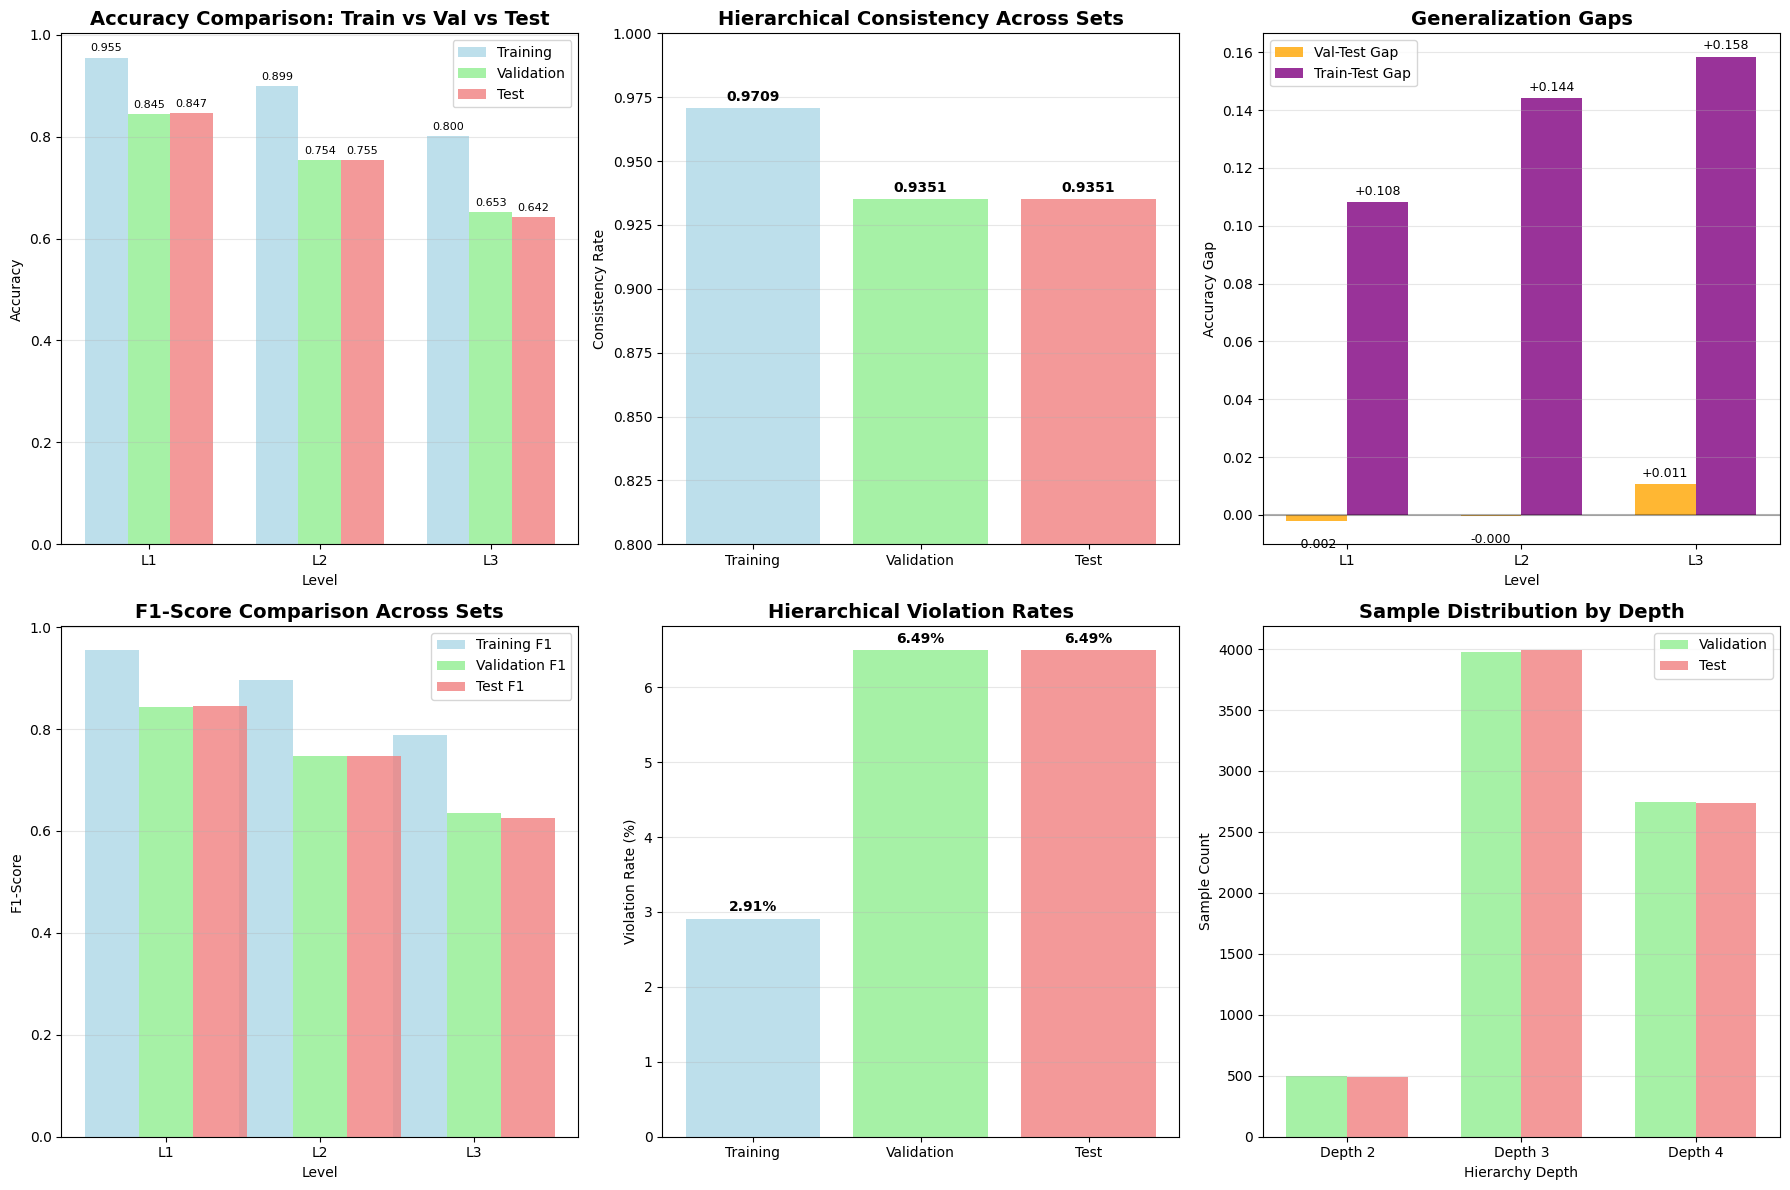


📈 Creating comprehensive visualization...
📊 Comprehensive visualization saved: /content/hierarchical_training_checkpoints/hierarchical_training_analysis_20250915_105611.png


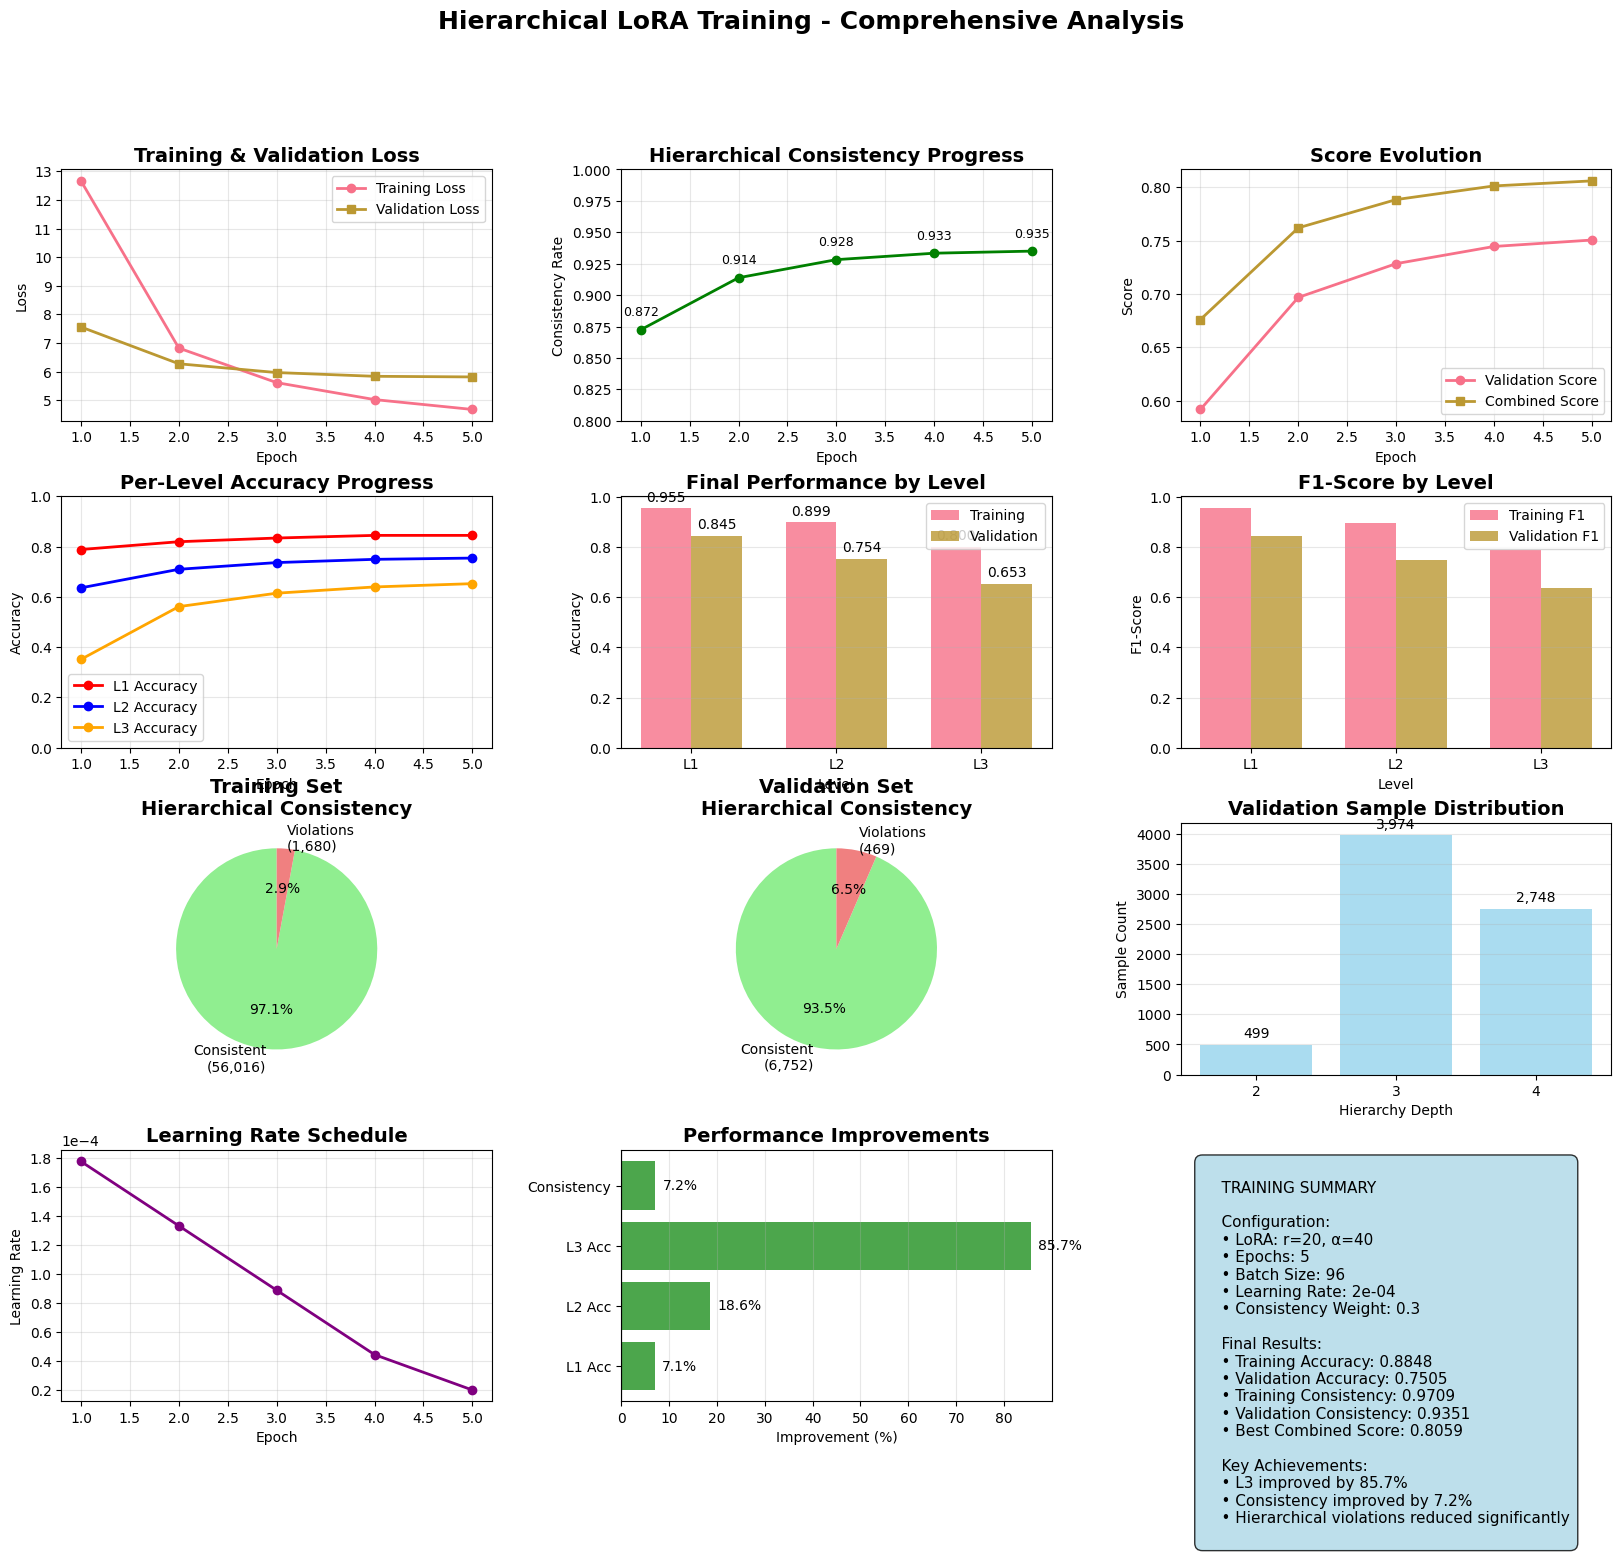

{'test_comparison': '/content/hierarchical_training_checkpoints/test_set_comparison_20250915_105609.png',
 'comprehensive': '/content/hierarchical_training_checkpoints/hierarchical_training_analysis_20250915_105611.png'}

In [14]:
complete_analysis_with_test()